# Calculate dimensionality of neural activity

Notebook created: 6/29/26
Studying multiload models

Comparing dimensionality of load1 vs load3

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-07-01 14:17:15.997099: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 14:17:16.005065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 14:17:16.014028: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 14:17:16.016700: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 14:17:16.024215: I tensorflow/core/platform/cpu_feature_guar

In [2]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

condn_phrase = 'delay'
condn_num = 150

## First load the stimsets

### visualize datasets

In [3]:
def visualize_dataset(trial_labels):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    
    # first plot is how many match/mismatch trials per load
    load_match_labels = np.unique(trial_labels[:,:2], axis=0)
    counts = [np.sum(np.all(trial_labels[:,:2] == lm, axis=1)) for lm in load_match_labels]
    axs[0].bar(range(len(load_match_labels)), counts)
    axs[0].set_xticks(range(len(load_match_labels)))
    axs[0].set_xticklabels([f"Load{lm[0]}, {'match' if lm[1] == 1 else 'mismatch'}" for lm in load_match_labels], rotation=90)
    axs[0].set_title("Number of trials per load and label")

    # second plot is stimulus presentation counts for load 1
    load1_idxs = np.where(trial_labels[:,0] == 1)[0]
    stims, counts = np.unique(trial_labels[load1_idxs, 2], return_counts=True)
    stims = stims.astype(int)  # ensure stims are integers for labeling
    axs[1].bar(stims, counts)
    axs[1].set_xticks(stims)
    axs[1].set_xticklabels([f"Stim {s}" for s in stims])
    axs[1].set_title("Stim counts for load 1")
    
    # third plot is stimulus presentation counts for load 3
    # 3 ticks for load 3, one for each position, 4 smaller bars for each tick, one for each stimulus
    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    for i, position in enumerate([2, 3, 4]):
        stims, counts = np.unique(trial_labels[load3_idxs, position], return_counts=True)
        axs[2].bar(i + np.arange(len(stims)) * 0.2, counts, width=0.2, label=[f"Stim {s}" for s in stims])
    axs[2].set_xticks([i + 0.3 for i in range(3)])
    axs[2].set_xticklabels([f"Position {p}" for p in range(3)])
    axs[2].legend()
    axs[2].set_title("Stim counts for load 3")
    axs[2].set_xlabel("Position")
    
    # plt.tight_layout()
    plt.show()

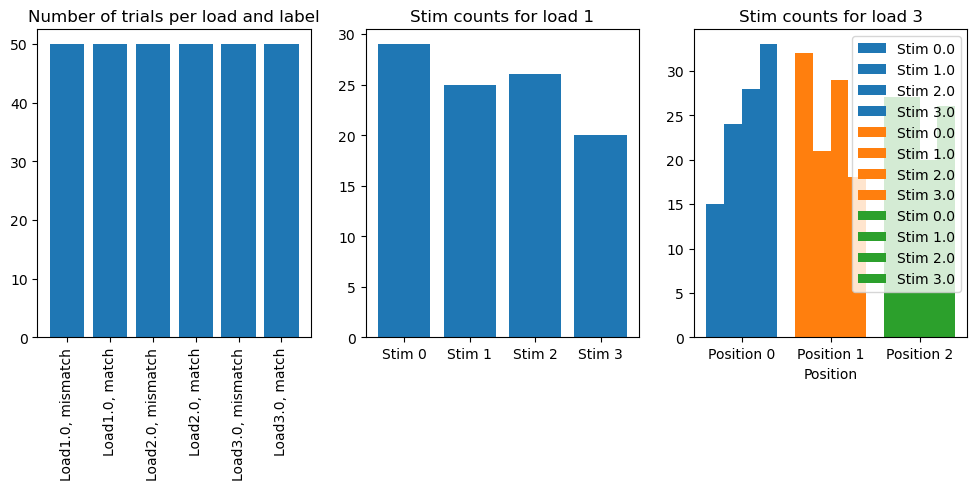

In [4]:
model_name = model_names[0]

trial_labels_match, trial_perfs_match, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

visualize_dataset(trial_labels_match)

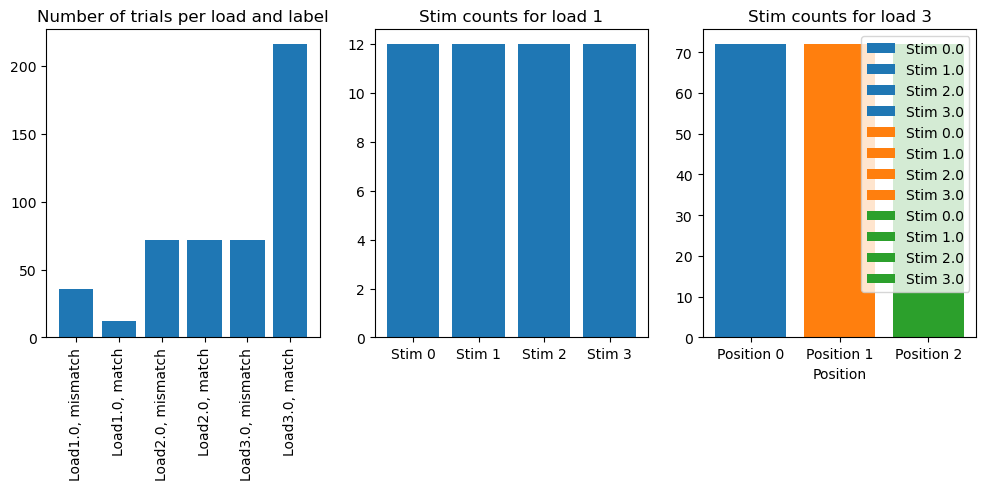

In [5]:
trial_labels_stims, trial_perfs_stims, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_stims',
        all_models_dir=all_models_dir
    )

visualize_dataset(trial_labels_stims)

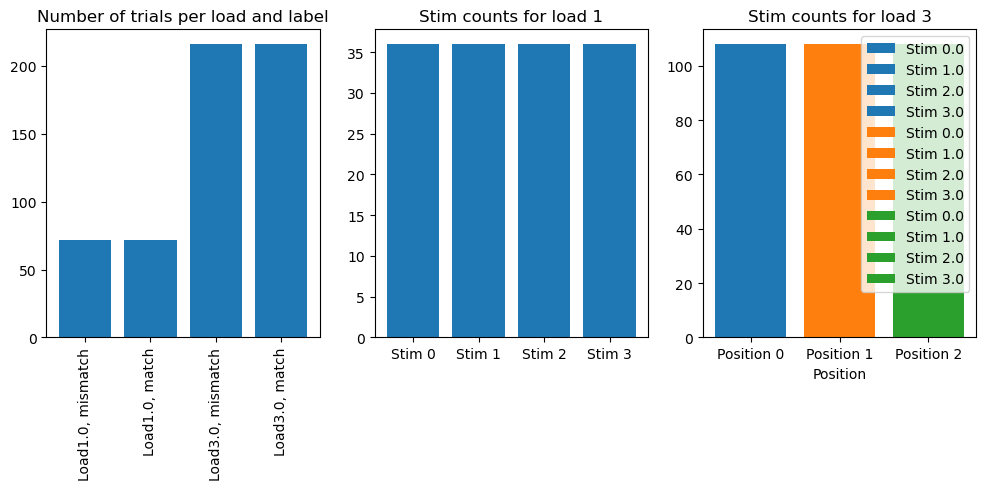

In [11]:
trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )

visualize_dataset(trial_labels_balance)

## testing normal PCA

### entire trial

#### one model

In [5]:
model_name = model_names[0] 

other_labels='precomputed.'
_, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )

In [ ]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

delay_start = settings["stim_on"] + settings["stim_dur"]*

In [ ]:
# calculate effective dimensionality for each load

# let's start by getting the firing rates only in correct trials
correct_idxs = np.where(trial_perfs_balance == 1)[0]
rates_corr = rates_data_balance[correct_idxs, :, 25:] # trials x neurons x time
trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels

# get all load1
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# get dimensionality for each load
load1_rates = rates_corr[load1_idxs, :, :] # trials x neurons x time
load3_rates = rates_corr[load3_idxs, :, :] # trials x neurons x time

from sklearn.decomposition import PCA
PCA_load1 = PCA(n_components=10) 
PCA_load1.fit(load1_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
PCA_load3 = PCA(n_components=10)
PCA_load3.fit(load3_rates.mean(axis=0)) # mean across trials; PCA of neurons x time

U_load1 = PCA_load1.components_ # comp x time
U_load3 = PCA_load3.components_ # comp x time

print(U_load1.shape, U_load3.shape)

Number of correct load 1 trials: 133
Number of correct load 3 trials: 296
Variance explained by Load 1: [0.884 0.091 0.013 0.005 0.004 0.001 0.001 0.    0.    0.   ]
Variance explained by Load 3: [0.846 0.114 0.021 0.008 0.007 0.002 0.001 0.001 0.    0.   ]


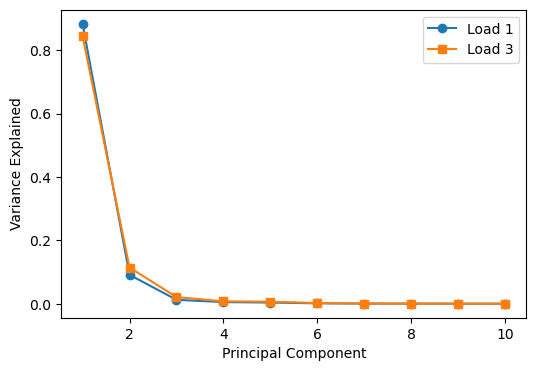

In [22]:
# plot variance explained
plt.figure(figsize=(6,4))
plt.plot(np.arange(1,11), PCA_load1.explained_variance_ratio_, 'o-', label='Load 1')
plt.plot(np.arange(1,11), PCA_load3.explained_variance_ratio_, 's-', label='Load 3')
print("Number of correct load 1 trials:", len(load1_idxs))
print("Number of correct load 3 trials:", len(load3_idxs))
print("Variance explained by Load 1:", np.round(PCA_load1.explained_variance_ratio_, 3))
print("Variance explained by Load 3:", np.round(PCA_load3.explained_variance_ratio_, 3))
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()

Load 1.0, Match -1.0: 61 trials
Variance explained: [0.867 0.107 0.012 0.008 0.002 0.002 0.001 0.    0.    0.   ]
Load 1.0, Match 1.0: 72 trials
Variance explained: [0.877 0.083 0.018 0.013 0.004 0.002 0.001 0.001 0.    0.   ]
Load 3.0, Match -1.0: 199 trials
Variance explained: [0.844 0.121 0.021 0.008 0.002 0.002 0.001 0.    0.    0.   ]
Load 3.0, Match 1.0: 97 trials
Variance explained: [0.814 0.101 0.048 0.021 0.01  0.003 0.001 0.001 0.    0.   ]


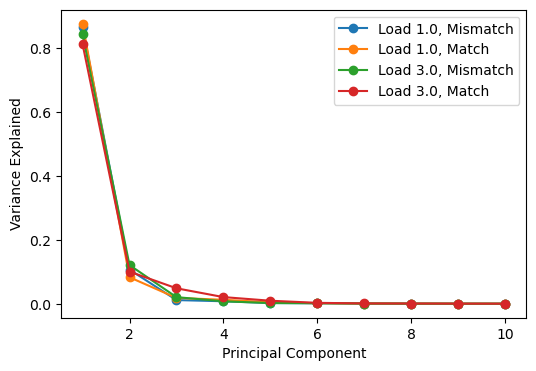

In [23]:
# calculate effective dimensionality for each load — split by match/mismatch trials

# let's start by getting the mean firing rates for each neuron across trial types, only in correct trials
correct_idxs = np.where(trial_perfs_balance == 1)[0]
rates_corr = rates_data_balance[correct_idxs, :, 25:] # trials x neurons x time
trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels

# get all combinations
trial_combos = np.unique(trial_labels_corr[:, :2], axis=0) # unique combinations of load and match/mismatch

plt.figure(figsize=(6,4))
for load, match in trial_combos:
    combo_idxs = np.where((trial_labels_corr[:, 0] == load) & (trial_labels_corr[:, 1] == match))[0]
    print(f"Load {load}, Match {match}: {len(combo_idxs)} trials")
    combo_rates = rates_corr[combo_idxs, :, :] # trials x neurons x time
    PCA_combo = PCA(n_components=10)
    PCA_combo.fit(combo_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
    U_combo = PCA_combo.components_ # comp x time
    plt.plot(np.arange(1,11), PCA_combo.explained_variance_ratio_, 'o-', label=f'Load {load}, {"Match" if match==1 else "Mismatch"}')
    print(f"Variance explained: {np.round(PCA_combo.explained_variance_ratio_, 3)}")
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()

#### multiple models

In [29]:
n_components = 10
varexps = np.zeros((len(model_names), n_components, 2)) # models x components x load

for i, model_name in enumerate(model_names):
    other_labels='precomputed.'
    _, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels='precomputed.',
            all_models_dir=all_models_dir
        )
    
    # let's start by getting the mean firing rates for each neuron across trial types, only in correct trials
    correct_idxs = np.where(trial_perfs_balance == 1)[0]
    rates_corr = rates_data_balance[correct_idxs, :, 25:] # trials x neurons x time
    trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels
    
    for j, load in enumerate([1, 3]):
        load_idxs = np.where(trial_labels_corr[:, 0] == load)[0]
        load_rates = rates_corr[load_idxs, :, :] # trials x neurons x time
        PCA_load = PCA(n_components=n_components)
        PCA_load.fit(load_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
        varexps[i, :, j] = PCA_load.explained_variance_ratio_

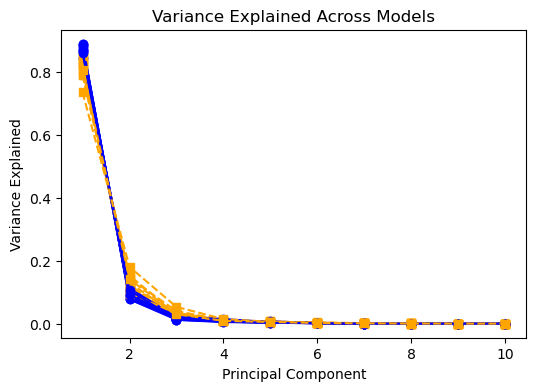

In [32]:
# plot varexps for each model
plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
colors = ['blue','orange','green','red']
for i, model_name in enumerate(model_names):
    plt.plot(x, varexps[i, :, 0], 'o-', color='blue')#, label=f'{model_name[-6:]} Load 1')
    plt.plot(x, varexps[i, :, 1], 's--', color='orange')#, label=f'{model_name[-6:]} Load 3')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained Across Models')
# plt.legend()
plt.show()

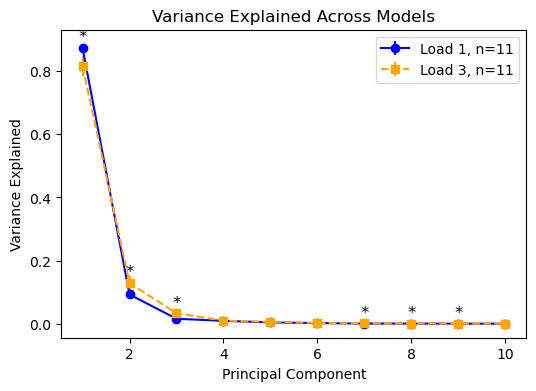

In [34]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
mean_varexps = np.mean(varexps, axis=0) # components x load
std_varexps = np.std(varexps, axis=0)
plt.errorbar(x, mean_varexps[:, 0], yerr=std_varexps[:, 0], fmt='o-', color='blue', label=f'Load 1, n={len(model_names)}')
plt.errorbar(x, mean_varexps[:, 1], yerr=std_varexps[:, 1], fmt='s--', color='orange', label=f'Load 3, n={len(model_names)}')
for i in range(n_components):
    p, _ = wilcoxon(varexps[:, i, 0], varexps[:, i, 1])
    if p < 0.05:
        plt.text(x[i], max(mean_varexps[i, 0], mean_varexps[i, 1]) + 0.01, '*', ha='center', va='bottom', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained Across Models')
plt.legend()
plt.show()

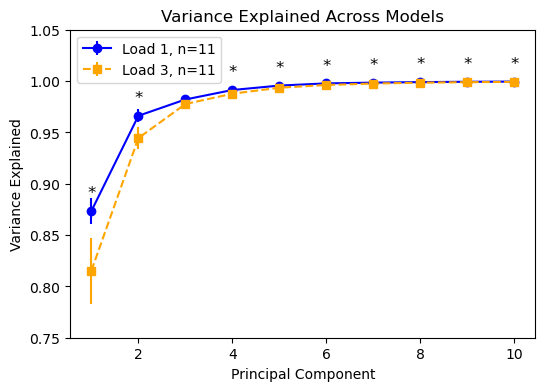

In [43]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
varexp_runningsum = np.cumsum(varexps, axis=1) # models x components x load
mean_varexps = np.mean(varexp_runningsum, axis=0) # components x load
std_varexps = np.std(varexp_runningsum, axis=0)
plt.errorbar(x, mean_varexps[:, 0], yerr=std_varexps[:, 0], fmt='o-', color='blue', label=f'Load 1, n={len(model_names)}')
plt.errorbar(x, mean_varexps[:, 1], yerr=std_varexps[:, 1], fmt='s--', color='orange', label=f'Load 3, n={len(model_names)}')
for i in range(n_components):
    p, _ = wilcoxon(varexp_runningsum[:, i, 0], varexp_runningsum[:, i, 1])
    if p < 0.05:
        plt.text(x[i], max(mean_varexps[i, 0], mean_varexps[i, 1]) + 0.01, '*', ha='center', va='bottom', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.ylim(0.75, 1.05)
plt.title('Variance Explained Across Models')
plt.legend()
# plt.tight_layout()
plt.show()

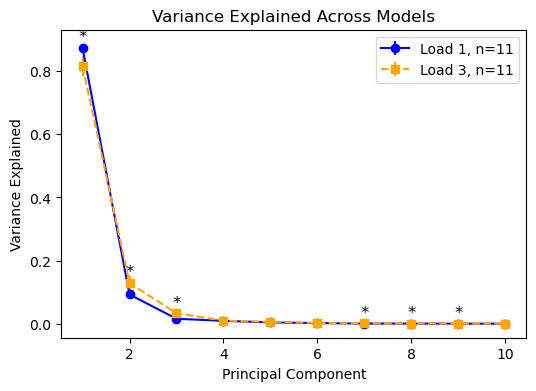

In [ ]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

# calculated summed variance explained when adding components together
varexps_added = np.sum(varexps, axis=1)

plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
mean_varexps = np.mean(varexps, axis=0) # components x load
std_varexps = np.std(varexps, axis=0)
plt.errorbar(x, mean_varexps[:, 0], yerr=std_varexps[:, 0], fmt='o-', color='blue', label=f'Load 1, n={len(model_names)}')
plt.errorbar(x, mean_varexps[:, 1], yerr=std_varexps[:, 1], fmt='s--', color='orange', label=f'Load 3, n={len(model_names)}')
for i in range(n_components):
    p, _ = wilcoxon(varexps[:, i, 0], varexps[:, i, 1])
    if p < 0.05:
        plt.text(x[i], max(mean_varexps[i, 0], mean_varexps[i, 1]) + 0.01, '*', ha='center', va='bottom', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained Across Models')
plt.legend()
plt.show()

In [44]:
n_components = 10
varexps = np.zeros((len(model_names), n_components, 4)) # models x components x load-match/mismatch

for i, model_name in enumerate(model_names):
    other_labels='precomputed.'
    _, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels='precomputed.',
            all_models_dir=all_models_dir
        )
    
    # let's start by getting the mean firing rates for each neuron across trial types, only in correct trials
    correct_idxs = np.where(trial_perfs_balance == 1)[0]
    rates_corr = rates_data_balance[correct_idxs, :, 25:] # trials x neurons x time
    trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels
    
    # get all combinations
    trial_combos = np.unique(trial_labels_corr[:, :2], axis=0) # unique combinations of load and match/mismatch
    
    for j, (load, match) in enumerate(trial_combos):
        combo_idxs = np.where((trial_labels_corr[:, 0] == load) & (trial_labels_corr[:, 1] == match))[0]
        combo_rates = rates_corr[combo_idxs, :, :] # trials x neurons x time
        PCA_combo = PCA(n_components=n_components)
        PCA_combo.fit(combo_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
        varexps[i, :, j] = PCA_combo.explained_variance_ratio_

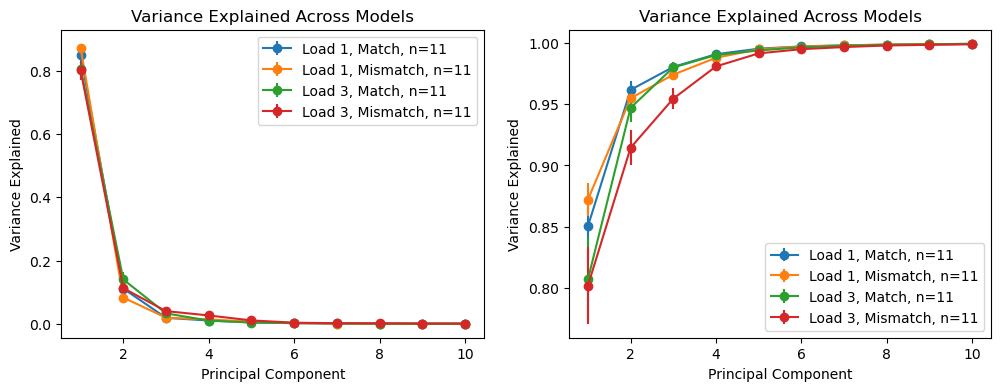

In [47]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# make subplots for varexps and cumsum
varexps_runningsum = np.cumsum(varexps, axis=1) # models x components x load-match/mismatch
x = np.arange(1, n_components+1)

# subplot1
for i, ve in enumerate([varexps, varexps_runningsum]):
    mean_varexps = np.mean(ve, axis=0) # components x load
    std_varexps = np.std(ve, axis=0)
    for j in range(4):
        axs[i].errorbar(x, mean_varexps[:, j], yerr=std_varexps[:, j], fmt='o-', label=f'Load {1 if j<2 else 3}, {"Match" if j%2==0 else "Mismatch"}, n={len(model_names)}')
    axs[i].set_xlabel('Principal Component')
    axs[i].set_ylabel('Variance Explained')
    axs[i].set_title('Variance Explained Across Models')
    axs[i].legend()
plt.show()

### maintenance only

#### one model

In [3]:
model_name = model_names[10] 

other_labels='precomputed.'
_, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )

In [4]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}


In [6]:
# calculate effective dimensionality for each load

# let's start by getting the firing rates only in correct trials
correct_idxs = np.where(trial_perfs_balance == 1)[0]
rates_corr = rates_data_balance[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

# get all load1
load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

# get dimensionality for each load
load1_rates = rates_maint[load1_idxs, :, :] # trials x neurons x time
load3_rates = rates_maint[load3_idxs, :, :] # trials x neurons x time

from sklearn.decomposition import PCA
PCA_load1 = PCA(n_components=10) 
PCA_load1.fit(load1_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
PCA_load3 = PCA(n_components=10)
PCA_load3.fit(load3_rates.mean(axis=0)) # mean across trials; PCA of neurons x time

U_load1 = PCA_load1.components_ # comp x time
U_load3 = PCA_load3.components_ # comp x time

print(U_load1.shape, U_load3.shape)

(10, 150) (10, 150)


#### effective dimensionality

Number of correct load 1 trials: 137
Number of correct load 3 trials: 280
Variance explained by Load 1: [0.928 0.067 0.004 0.001 0.    0.    0.    0.    0.    0.   ]
Variance explained by Load 3: [0.922 0.072 0.005 0.001 0.    0.    0.    0.    0.    0.   ]


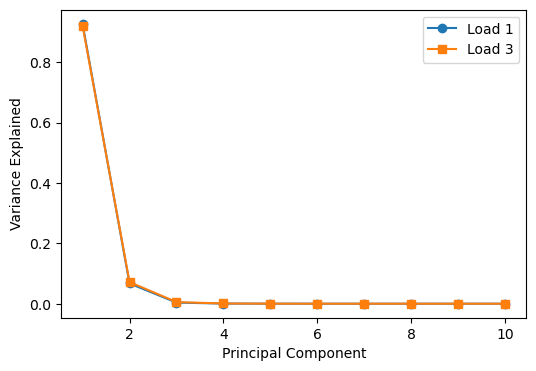

In [16]:
# plot variance explained
plt.figure(figsize=(6,4))
plt.plot(np.arange(1,11), PCA_load1.explained_variance_ratio_, 'o-', label='Load 1')
plt.plot(np.arange(1,11), PCA_load3.explained_variance_ratio_, 's-', label='Load 3')
print("Number of correct load 1 trials:", len(load1_idxs))
print("Number of correct load 3 trials:", len(load3_idxs))
print("Variance explained by Load 1:", np.round(PCA_load1.explained_variance_ratio_, 3))
print("Variance explained by Load 3:", np.round(PCA_load3.explained_variance_ratio_, 3))
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()

Load 1.0, Match -1.0: 66 trials
Variance explained: [0.927 0.068 0.004 0.001 0.    0.    0.    0.    0.    0.   ]
Load 1.0, Match 1.0: 71 trials
Variance explained: [0.928 0.067 0.004 0.001 0.    0.    0.    0.    0.    0.   ]
Load 3.0, Match -1.0: 166 trials
Variance explained: [0.924 0.07  0.005 0.001 0.    0.    0.    0.    0.    0.   ]
Load 3.0, Match 1.0: 114 trials
Variance explained: [0.917 0.076 0.006 0.001 0.    0.    0.    0.    0.    0.   ]


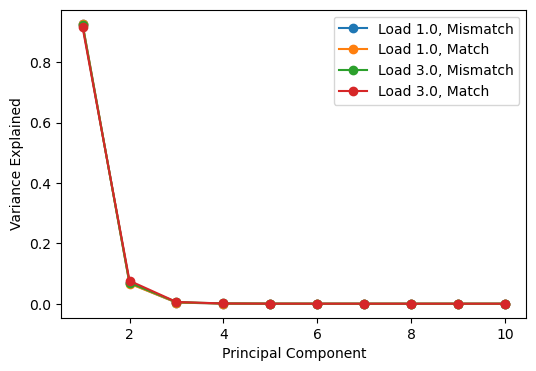

In [17]:
# calculate effective dimensionality for each load — split by match/mismatch trials

# let's start by getting the firing rates only in correct trials
correct_idxs = np.where(trial_perfs_balance == 1)[0]
rates_corr = rates_data_balance[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]
    
# get all combinations
trial_combos = np.unique(trial_labels_corr[:, :2], axis=0) # unique combinations of load and match/mismatch

plt.figure(figsize=(6,4))
for load, match in trial_combos:
    combo_idxs = np.where((trial_labels_corr[:, 0] == load) & (trial_labels_corr[:, 1] == match))[0]
    print(f"Load {load}, Match {match}: {len(combo_idxs)} trials")
    combo_rates = rates_maint[combo_idxs, :, :] # trials x neurons x time
    PCA_combo = PCA(n_components=10)
    PCA_combo.fit(combo_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
    U_combo = PCA_combo.components_ # comp x time
    plt.plot(np.arange(1,11), PCA_combo.explained_variance_ratio_, 'o-', label=f'Load {load}, {"Match" if match==1 else "Mismatch"}')
    print(f"Variance explained: {np.round(PCA_combo.explained_variance_ratio_, 3)}")
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()

#### 3d plots

In [7]:
# PCA of load1 and load3 together

# trials x neurons x time -> reshape so each (trial, timepoint) is a row
n_trials_load1, n_neurons, n_time = load1_rates.shape
n_trials_load3, _, _ = load3_rates.shape
load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

X = np.concatenate([load1_vectors, load3_vectors], axis=0)  # trials x neurons
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd

pca = PCA(n_components=300)
scores = pca.fit_transform(Xz)  # trials x components

n1 = load1_vectors.shape[0]
scores1, scores3 = scores[:n1], scores[n1:]

[0.121 0.23  0.333 0.406 0.444 0.474 0.501 0.525 0.547 0.566 0.583 0.6
 0.61  0.619 0.629 0.637 0.645 0.651 0.657 0.663 0.668 0.673 0.678 0.682
 0.687 0.691 0.695 0.698 0.702 0.705 0.708 0.712 0.715 0.718 0.72  0.723
 0.726 0.729 0.731 0.734 0.736 0.738 0.741 0.743 0.745 0.747 0.749 0.751
 0.753 0.755]


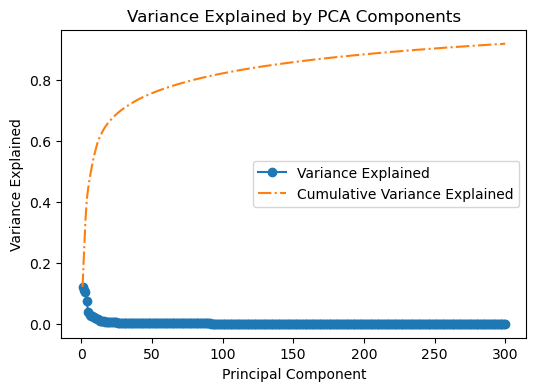

In [19]:
# varexp plot

varexp = pca.explained_variance_ratio_
varexp_cumsum = np.cumsum(varexp)
print(np.round(varexp_cumsum[:50], 3))  # print first 10 cumulative variance explained

plt.figure(figsize=(6,4))
plt.plot(np.arange(1,301), varexp, 'o-', label='Variance Explained')
plt.plot(np.arange(1,301), varexp_cumsum, '-.', label='Cumulative Variance Explained')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by PCA Components')
plt.legend()
plt.show()

[0.121 0.11  0.103 0.074 0.037 0.03  0.027 0.024 0.022 0.019 0.017 0.016
 0.01  0.009 0.009 0.009 0.008 0.007 0.006 0.006 0.005 0.005 0.005 0.005
 0.004 0.004 0.004 0.004 0.004 0.003 0.003 0.003 0.003 0.003 0.003 0.003
 0.003 0.003 0.003 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002
 0.002 0.002]


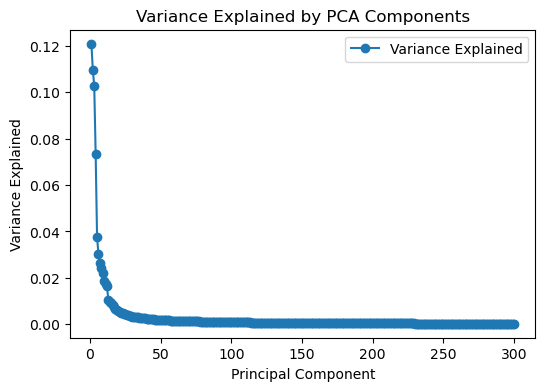

In [20]:
# varexp plot

varexp = pca.explained_variance_ratio_
varexp_cumsum = np.cumsum(varexp)
print(np.round(varexp[:50], 3))  # print first 10 cumulative variance explained

plt.figure(figsize=(6,4))
plt.plot(np.arange(1,301), varexp, 'o-', label='Variance Explained')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by PCA Components')
plt.legend()
plt.show()

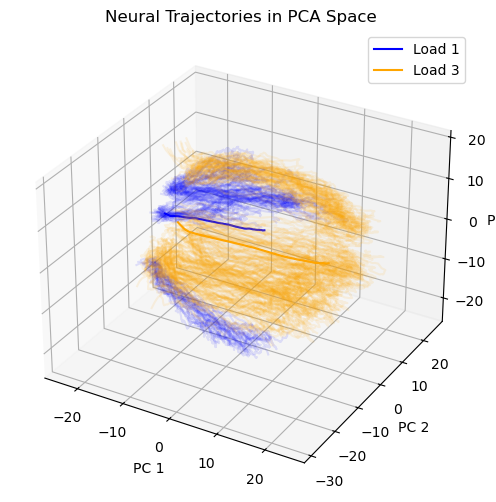

In [9]:
load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
load3_comps = scores3.reshape(n_trials_load3, n_time, -1)

# plot the first 3 components for each load
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(load1_comps.mean(axis=0)[:, 0], load1_comps.mean(axis=0)[:, 1], load1_comps.mean(axis=0)[:, 2], label='Load 1', color='blue')
ax.plot(load3_comps.mean(axis=0)[:, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
    ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='blue', alpha=0.1)
for i in range(n_trials_load3):
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color='orange', alpha=0.1)
    
# # arrows to indicate direction of time
# for load_comps, color in zip([load1_comps, load3_comps], ['blue', 'orange']):
#     mean_traj = load_comps.mean(axis=0)
#     for t in range(0, n_time, 10):
#         ax.quiver(mean_traj[t, 0], mean_traj[t, 1], mean_traj[t, 2],
#                   mean_traj[min(t+1, n_time-1), 0] - mean_traj[t, 0],
#                   mean_traj[min(t+1, n_time-1), 1] - mean_traj[t, 1],
#                   mean_traj[min(t+1, n_time-1), 2] - mean_traj[t, 2],
#                   color=color, arrow_length_ratio=0.3)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_876855/2295129053.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


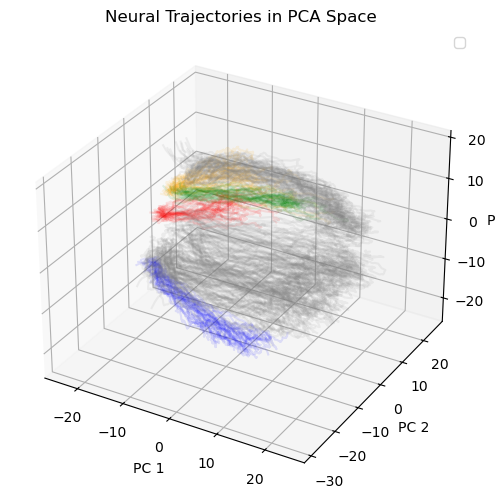

In [ ]:
# plot colored by stim1 identity

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1
load3_stims = trial_labels_corr[load3_idxs, 2].astype(int)  # stim1 for load 3

colors = ['blue','orange','red','green']
# lightly plot individual trials for each load
for i in range(n_trials_load1):
    ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color=colors[load1_stims[i]], alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color='gray', alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_876855/395078835.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


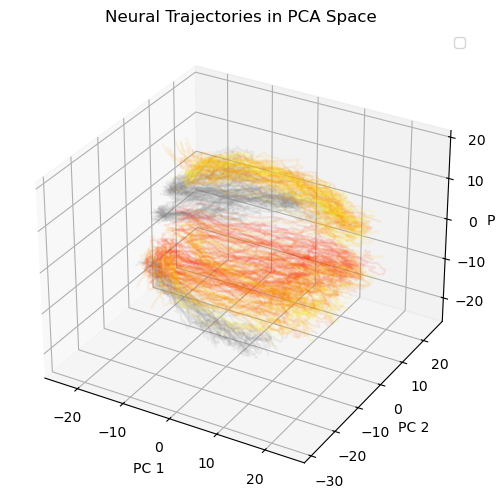

In [61]:
# make a graded colorscale for each combo
trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3
n_combos = len(trial_combos)
colors = plt.cm.autumn(np.linspace(0, 1, n_combos))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[combo_labels[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_910676/3269644451.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


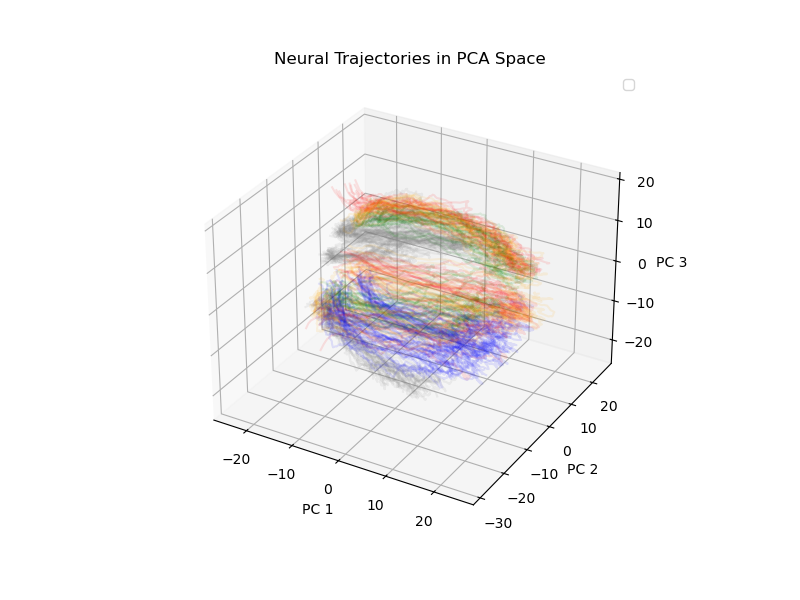

In [12]:
# color load3 by which was stim3

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3
%matplotlib ipympl

label_last = trial_labels_corr[load3_idxs, 4].astype(int)  # which stim was last
# label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
# n_combos = len(label_leftout)
# colors = plt.cm.autumn(np.linspace(0, 1, n_combos))
colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_last[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_876855/1937269895.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


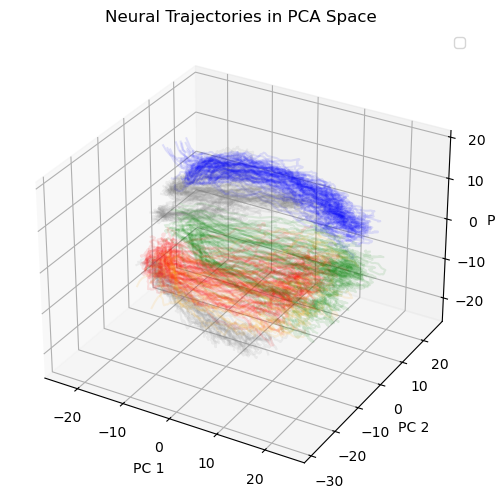

In [ ]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)
# colors = plt.cm.autumn(np.linspace(0, 1, n_combos))
colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_876855/2357261700.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


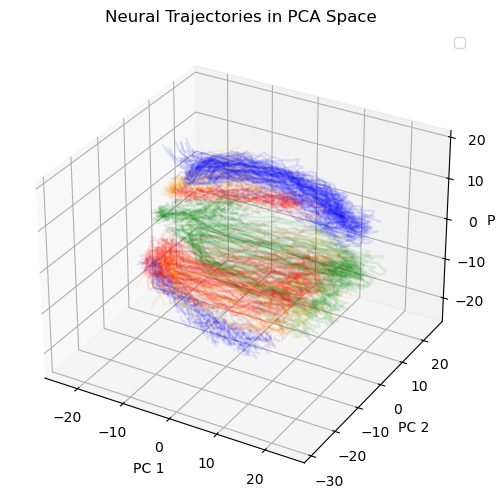

In [68]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], 
                color=colors[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

/tmp/ipykernel_876855/792329120.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


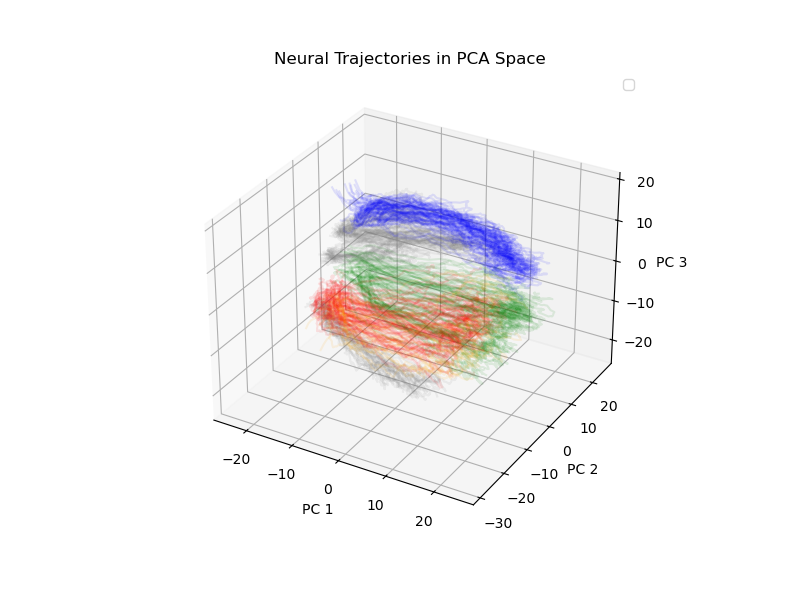

In [ ]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)
# colors = plt.cm.autumn(np.linspace(0, 1, n_combos))
colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
%matplotlib ipympl
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

In [75]:
import matplotlib.colors as mcolors
import colorsys

colors = ['blue', 'orange', 'green', 'red']

def shift_hue(color, amount=0.08):
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    h = (h + amount) % 1.0
    return colorsys.hls_to_rgb(h, l, s)

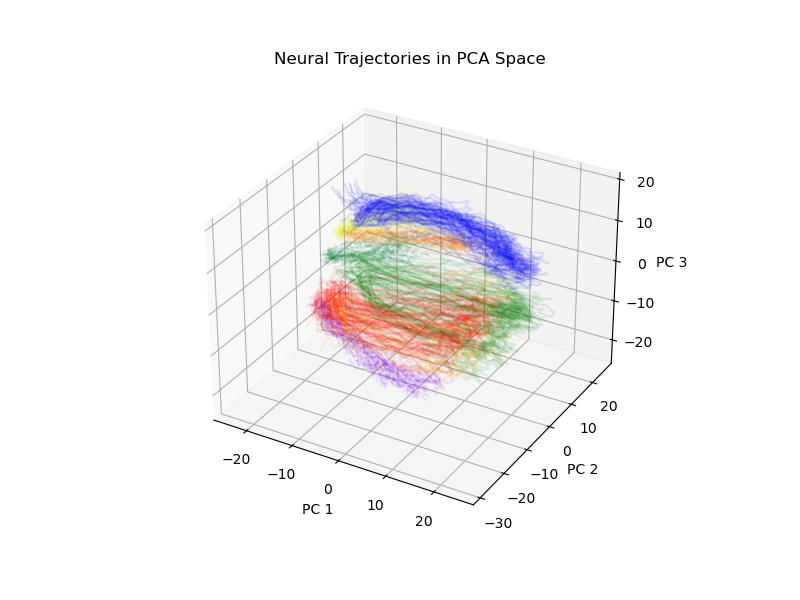

In [ ]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

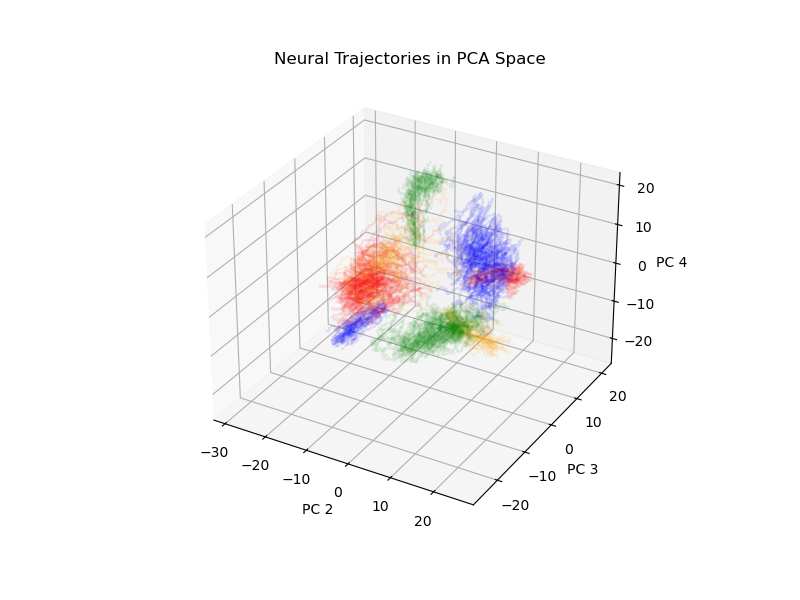

In [78]:
# plot PCs 2, 3, 4 (since PC1 is time)

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 1], load1_comps[i, :, 2], load1_comps[i, :, 3], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 1], load3_comps[i, :, 2], load3_comps[i, :, 3], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 2')
ax.set_ylabel('PC 3')
ax.set_zlabel('PC 4')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

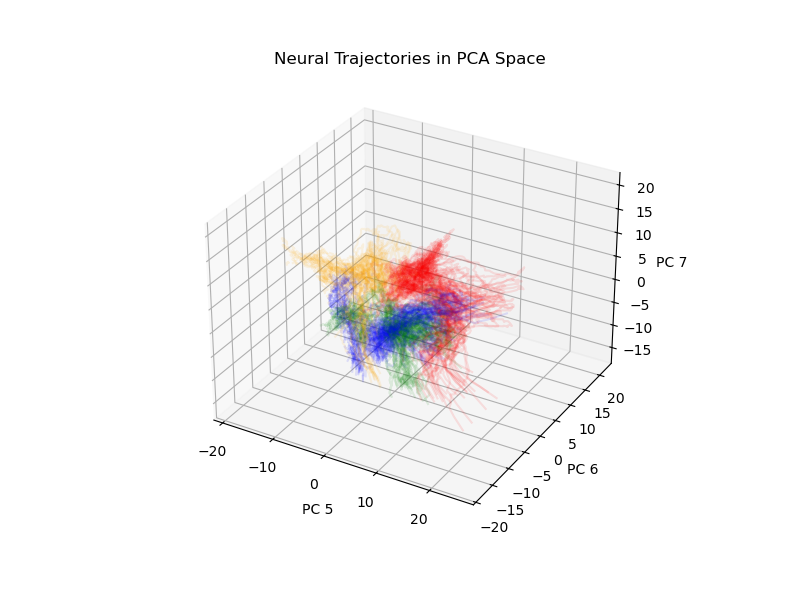

In [79]:
# plot PCs 5, 6, 7 (do any separate load lol)

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 4], load1_comps[i, :, 5], load1_comps[i, :, 6], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 4], load3_comps[i, :, 5], load3_comps[i, :, 6], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 5')
ax.set_ylabel('PC 6')
ax.set_zlabel('PC 7')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

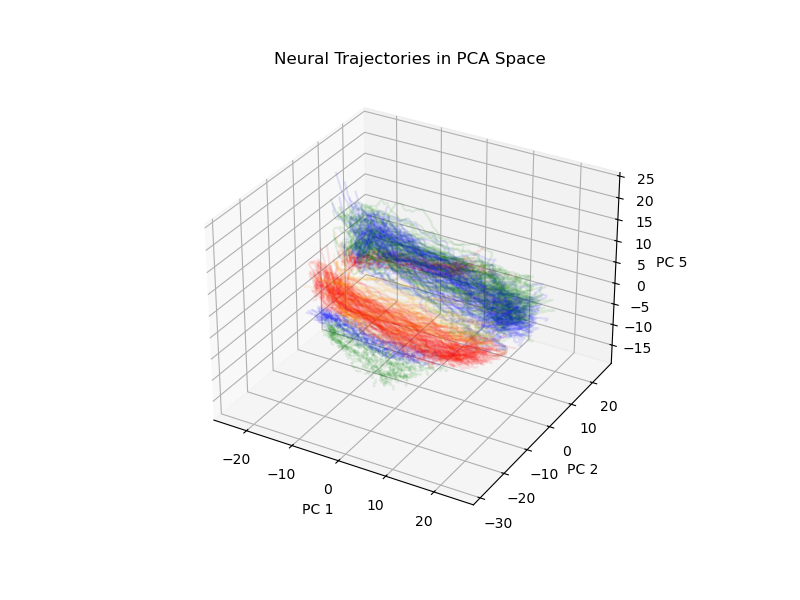

In [80]:
# plot PCs 1, 2, 5 (5 shows load?)

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

plot_PCS = [0, 1, 4]  # PCs to plot

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, plot_PCS[0]], load1_comps[i, :, plot_PCS[1]], load1_comps[i, :, plot_PCS[2]], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, plot_PCS[0]], load3_comps[i, :, plot_PCS[1]], load3_comps[i, :, plot_PCS[2]], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel(f'PC {plot_PCS[0] + 1}')
ax.set_ylabel(f'PC {plot_PCS[1] + 1}')
ax.set_zlabel(f'PC {plot_PCS[2] + 1}')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

Number of load-selective neurons: 836
load1: 197, load3: 639


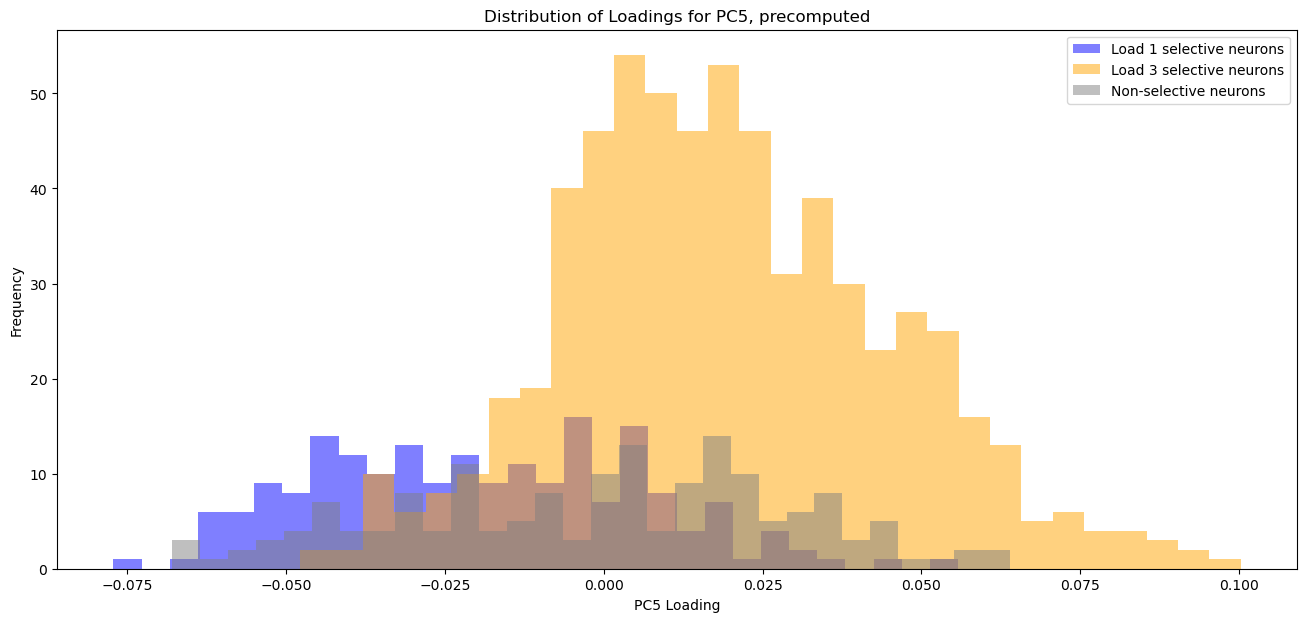

In [100]:
# which neurons / loadings are contributing more to PC5
PC5_loadings = pca.components_[4, :]  # loadings for PC5

load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
load_selective = np.where(~np.isnan(load_tuning))[0]  # neurons that are load-selective
print(f"Number of load-selective neurons: {len(load_selective)}")
print(f"load1: {np.sum(load_tuning==1)}, load3: {np.sum(load_tuning==3)}")

# plot the loadings for PC5
plt.figure(figsize=(16,7))
plt.hist(PC5_loadings[load_tuning==1], bins=30, alpha=0.5, label='Load 1 selective neurons', color='blue')
plt.hist(PC5_loadings[load_tuning==3], bins=30, alpha=0.5, label='Load 3 selective neurons', color='orange')
plt.hist(PC5_loadings[np.isnan(load_tuning)], bins=30, alpha=0.5, label='Non-selective neurons', color='gray')
plt.xlabel('PC5 Loading')
plt.ylabel('Frequency')
plt.title('Distribution of Loadings for PC5, precomputed')
plt.legend()
plt.show()

Number of load-selective neurons: 383
load1: 65, load3: 312


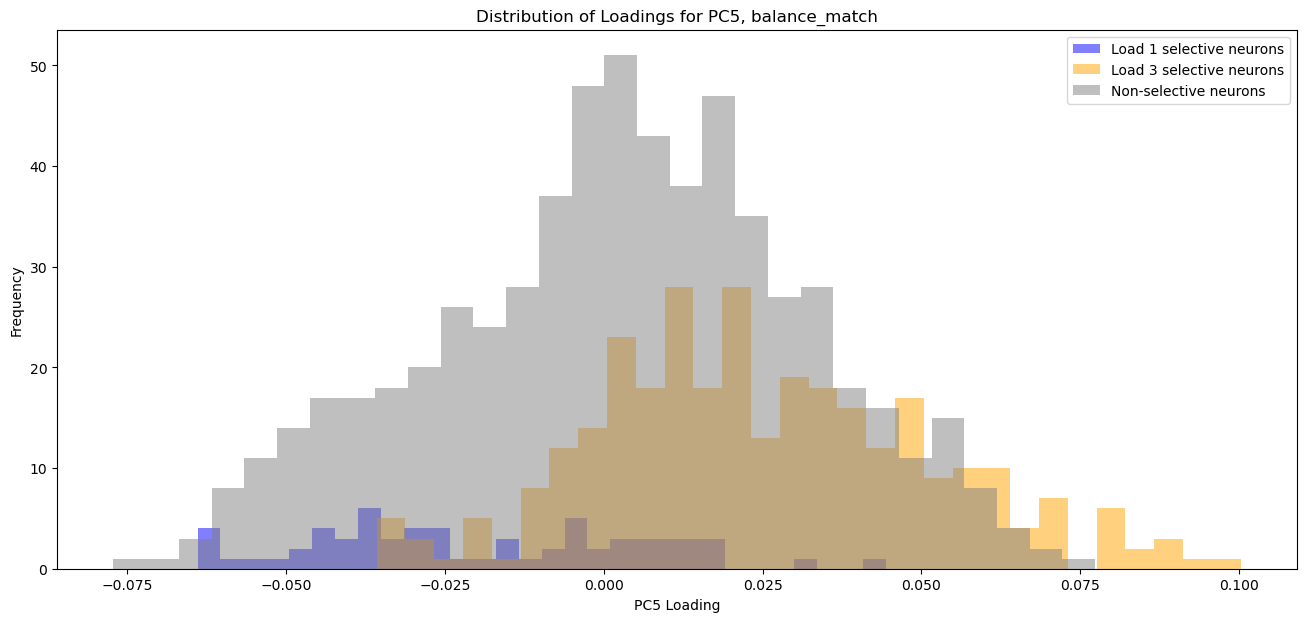

In [101]:
# which neurons / loadings are contributing more to PC5
PC5_loadings = pca.components_[4, :]  # loadings for PC5

load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)
load_selective = np.where(~np.isnan(load_tuning))[0]  # neurons that are load-selective
print(f"Number of load-selective neurons: {len(load_selective)}")
print(f"load1: {np.sum(load_tuning==1)}, load3: {np.sum(load_tuning==3)}")

# plot the loadings for PC5
plt.figure(figsize=(16,7))
plt.hist(PC5_loadings[load_tuning==1], bins=30, alpha=0.5, label='Load 1 selective neurons', color='blue')
plt.hist(PC5_loadings[load_tuning==3], bins=30, alpha=0.5, label='Load 3 selective neurons', color='orange')
plt.hist(PC5_loadings[np.isnan(load_tuning)], bins=30, alpha=0.5, label='Non-selective neurons', color='gray')
plt.xlabel('PC5 Loading')
plt.ylabel('Frequency')
plt.title('Distribution of Loadings for PC5, balance_match')
plt.legend()
plt.show()

Number of load-selective neurons: 466
load1: 53, load3: 396


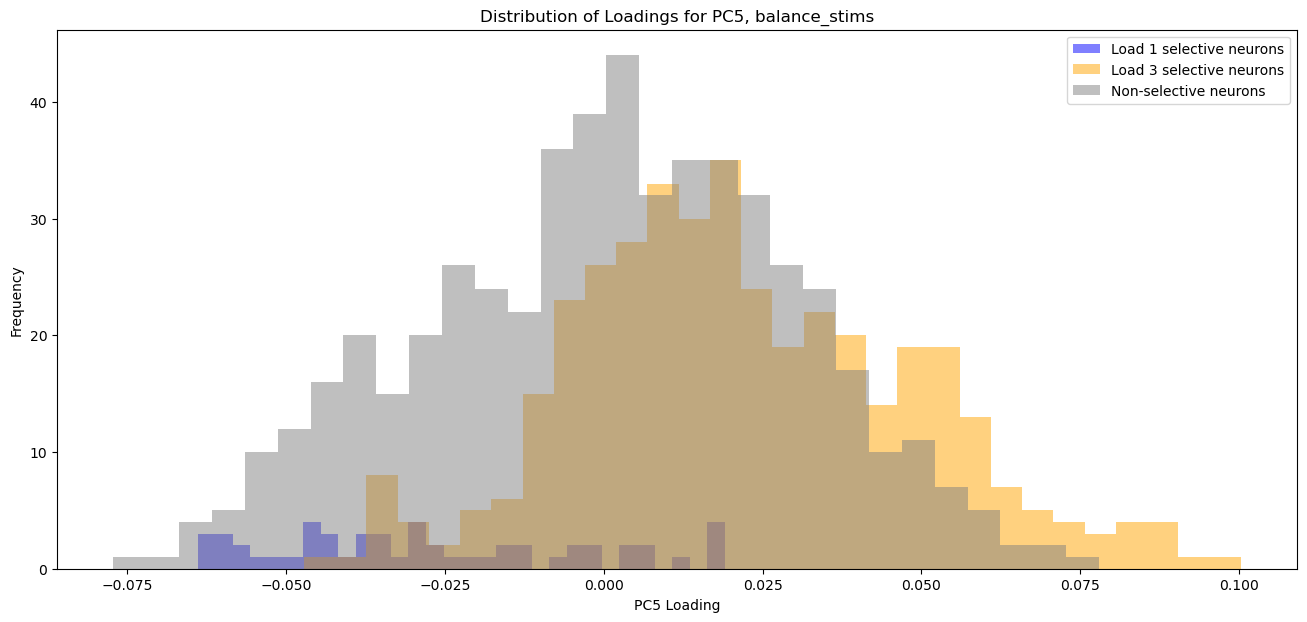

In [102]:
# which neurons / loadings are contributing more to PC5
PC5_loadings = pca.components_[4, :]  # loadings for PC5

load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
load_selective = np.where(~np.isnan(load_tuning))[0]  # neurons that are load-selective
print(f"Number of load-selective neurons: {len(load_selective)}")
print(f"load1: {np.sum(load_tuning==1)}, load3: {np.sum(load_tuning==3)}")

# plot the loadings for PC5
plt.figure(figsize=(16,7))
plt.hist(PC5_loadings[load_tuning==1], bins=30, alpha=0.5, label='Load 1 selective neurons', color='blue')
plt.hist(PC5_loadings[load_tuning==3], bins=30, alpha=0.5, label='Load 3 selective neurons', color='orange')
plt.hist(PC5_loadings[np.isnan(load_tuning)], bins=30, alpha=0.5, label='Non-selective neurons', color='gray')
plt.xlabel('PC5 Loading')
plt.ylabel('Frequency')
plt.title('Distribution of Loadings for PC5, balance_stims')
plt.legend()
plt.show()

### this model's load3-lesioned data

In [22]:
model_name

'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131'

In [ ]:
# data with load-3 neurons lesioned

load_lesion = 3
other_labels = f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)

_, rates_data_lesion = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels_lesion, trial_perfs_lesion, _ = ld.load_bhv_rate_data(
    model_name, condn_phrase, condn_num,
    other_labels=other_labels,
    all_models_dir=all_models_dir
)

In [24]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

In [25]:
# calculate effective dimensionality for each load — split by match/mismatch trials

# let's start by getting the firing rates only in correct trials
correct_idxs = np.where(trial_perfs_lesion == 1)[0]
rates_corr = rates_data_lesion[correct_idxs, :, :] # trials x neurons x time
trial_labels_corr = trial_labels_lesion[correct_idxs, :] # trials x labels

# cut trials to maintenance period only
rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
for i in range(rates_corr.shape[0]):
    load = trial_labels_corr[i, 0]
    delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
    delay_end = int(delay_start + settings["delay"])
    rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]

In [26]:
# Use the PCA from the non-lesioned data to project the lesioned data into the same PCA space

load1_idxs = np.where((trial_labels_corr[:, 0] == 1))[0]
load3_idxs = np.where((trial_labels_corr[:, 0] == 3))[0]

load1_rates = rates_maint[load1_idxs, :, :]  # trials x neurons x time
load3_rates = rates_maint[load3_idxs, :, :]  # trials x neurons x time

# trials x neurons x time -> reshape so each (trial, timepoint) is a row
n_trials_load1, n_neurons, n_time = load1_rates.shape
n_trials_load3, _, _ = load3_rates.shape
load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

X = np.concatenate([load1_vectors, load3_vectors], axis=0)  # trials x neurons
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd

scores = pca.transform(Xz)  # trials x components

n1 = load1_vectors.shape[0]
scores1, scores3 = scores[:n1], scores[n1:]

# pca = PCA(n_components=300)
# scores = pca.fit_transform(Xz)  # trials x components

# n1 = load1_vectors.shape[0]
# scores1, scores3 = scores[:n1], scores[n1:]

In [ ]:
def get_pca_data(rates_data, trial_perfs, trial_labels, settings):
    correct_idxs = np.where(trial_perfs == 1)[0]
    rates_corr = rates_data[correct_idxs, :, :] # trials x neurons x time
    trial_labels_corr = trial_labels[correct_idxs, :] # trials x labels

    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for i in range(rates_corr.shape[0]):
        load = trial_labels_corr[i, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[i, :, :] = rates_corr[i, :, delay_start:delay_end]
    
    load1_idxs = np.where((trial_labels_corr[:, 0] == 1))[0]
    load3_idxs = np.where((trial_labels_corr[:, 0] == 3))[0]

    load1_rates = rates_maint[load1_idxs, :, :]  # trials x neurons x time
    load3_rates = rates_maint[load3_idxs, :, :]  # trials x neurons x time

    # trials x neurons x time -> reshape so each (trial, timepoint) is a row
    n_trials_load1, n_neurons, n_time = load1_rates.shape
    n_trials_load3, _, _ = load3_rates.shape
    load1_vectors = load1_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons
    load3_vectors = load3_rates.transpose(0,2,1).reshape(-1, n_neurons)  # (trials*time) x neurons

    return load1_vectors, load3_vectors, n_trials_load1, n_trials_load3, n_neurons, n_time

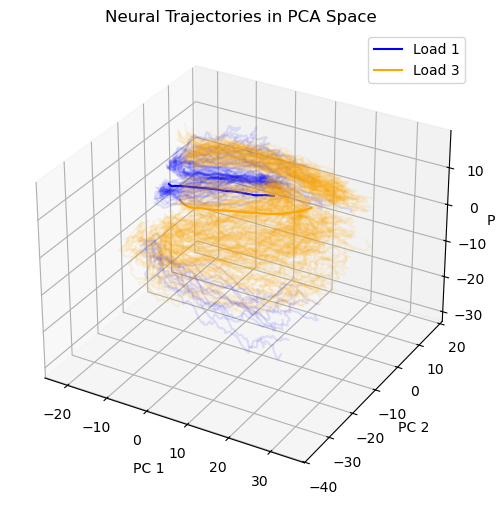

In [28]:
load1_comps = scores1.reshape(n_trials_load1, n_time, -1) # trials x time x components
load3_comps = scores3.reshape(n_trials_load3, n_time, -1)

# plot the first 3 components for each load
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(load1_comps.mean(axis=0)[:, 0], load1_comps.mean(axis=0)[:, 1], load1_comps.mean(axis=0)[:, 2], label='Load 1', color='blue')
ax.plot(load3_comps.mean(axis=0)[:, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
    ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='blue', alpha=0.1)
for i in range(n_trials_load3):
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color='orange', alpha=0.1)
    
# # arrows to indicate direction of time
# for load_comps, color in zip([load1_comps, load3_comps], ['blue', 'orange']):
#     mean_traj = load_comps.mean(axis=0)
#     for t in range(0, n_time, 10):
#         ax.quiver(mean_traj[t, 0], mean_traj[t, 1], mean_traj[t, 2],
#                   mean_traj[min(t+1, n_time-1), 0] - mean_traj[t, 0],
#                   mean_traj[min(t+1, n_time-1), 1] - mean_traj[t, 1],
#                   mean_traj[min(t+1, n_time-1), 2] - mean_traj[t, 2],
#                   color=color, arrow_length_ratio=0.3)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_906964/2073342413.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


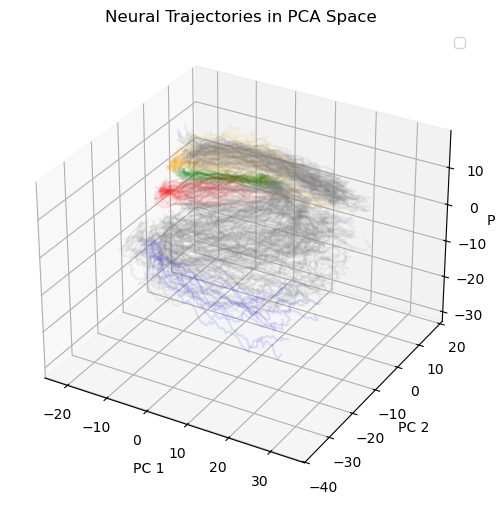

In [29]:
# plot colored by stim1 identity

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1
load3_stims = trial_labels_corr[load3_idxs, 2].astype(int)  # stim1 for load 3

colors = ['blue','orange','red','green']
# lightly plot individual trials for each load
for i in range(n_trials_load1):
    ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color=colors[load1_stims[i]], alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color='gray', alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_906964/395078835.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


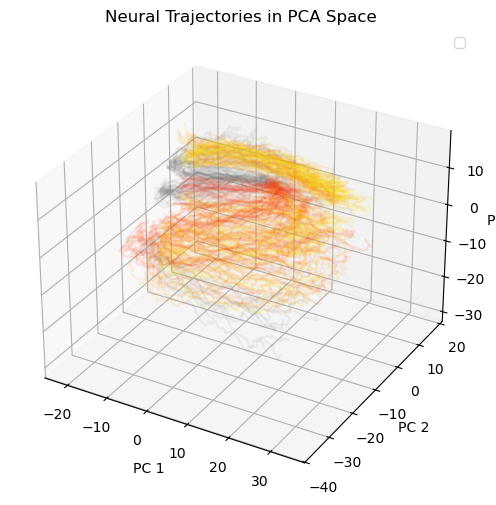

In [30]:
# make a graded colorscale for each combo
trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3
n_combos = len(trial_combos)
colors = plt.cm.autumn(np.linspace(0, 1, n_combos))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[combo_labels[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

/tmp/ipykernel_906964/1937269895.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


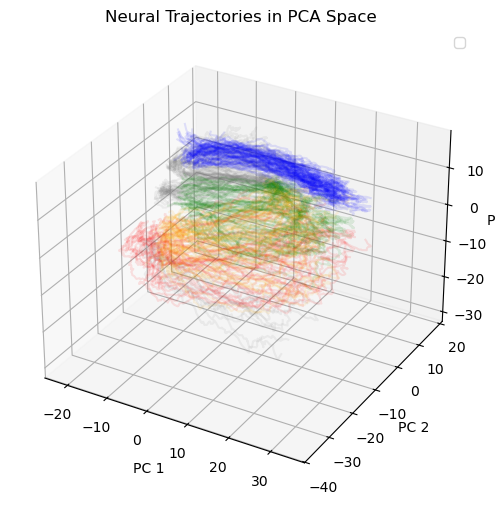

In [31]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)
# colors = plt.cm.autumn(np.linspace(0, 1, n_combos))
colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

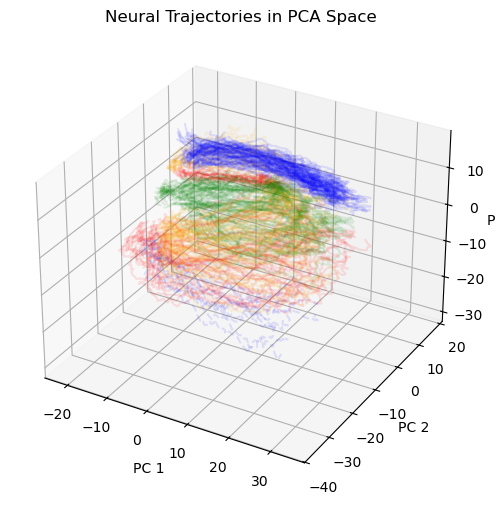

In [32]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], 
                color=colors[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

/tmp/ipykernel_906964/4220665312.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


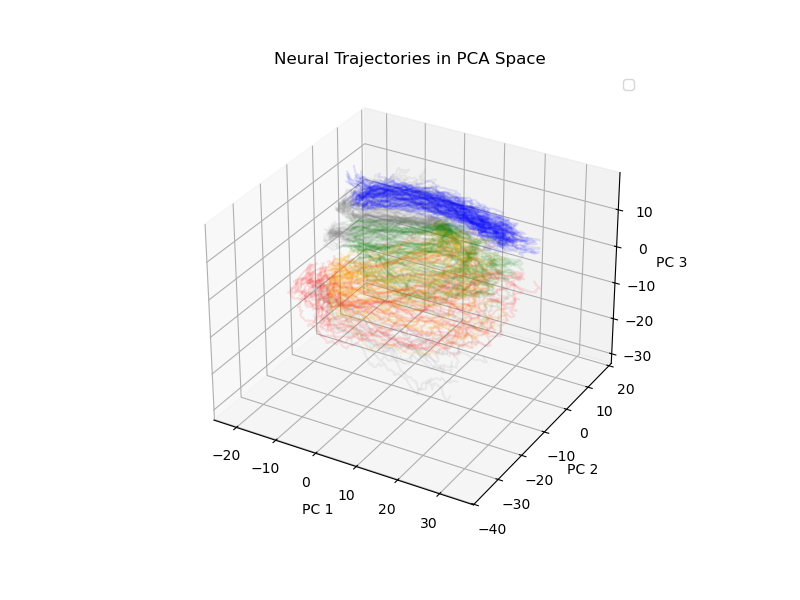

In [34]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)
# colors = plt.cm.autumn(np.linspace(0, 1, n_combos))
colors = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
%matplotlib ipympl
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1],  load3_comps[i, :, 2], 
            color=colors[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

In [129]:
import matplotlib.colors as mcolors
import colorsys

colors = ['blue', 'orange', 'green', 'red']

def shift_hue(color, amount=0.08):
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    h = (h + amount) % 1.0
    return colorsys.hls_to_rgb(h, l, s)

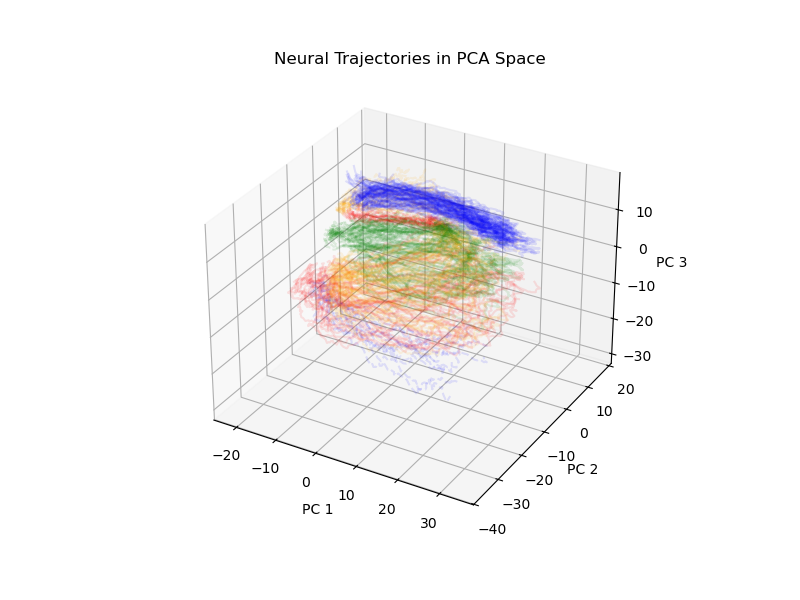

In [36]:
# color load3 by which was left out

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
# colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

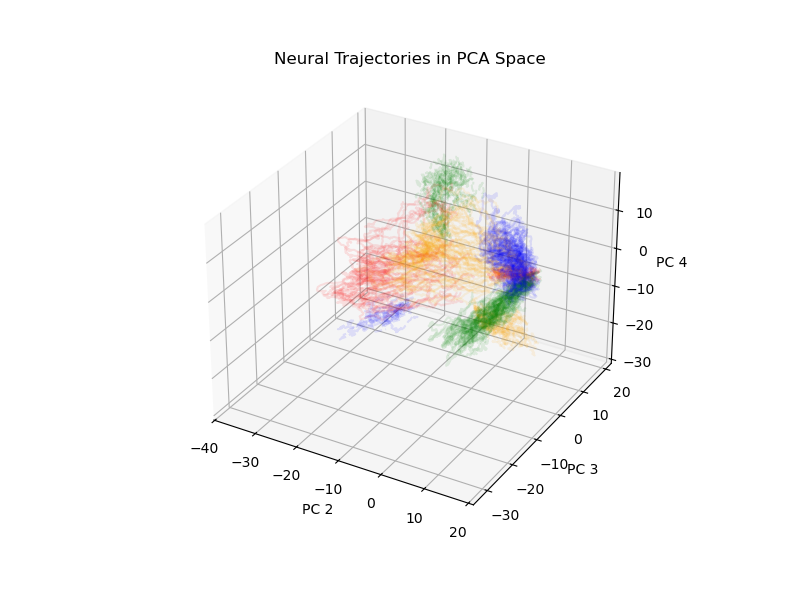

In [38]:
# plot PCs 2, 3, 4 (since PC1 is time)

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
# colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, 1], load1_comps[i, :, 2], load1_comps[i, :, 3], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, 1], load3_comps[i, :, 2], load3_comps[i, :, 3], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel('PC 2')
ax.set_ylabel('PC 3')
ax.set_zlabel('PC 4')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

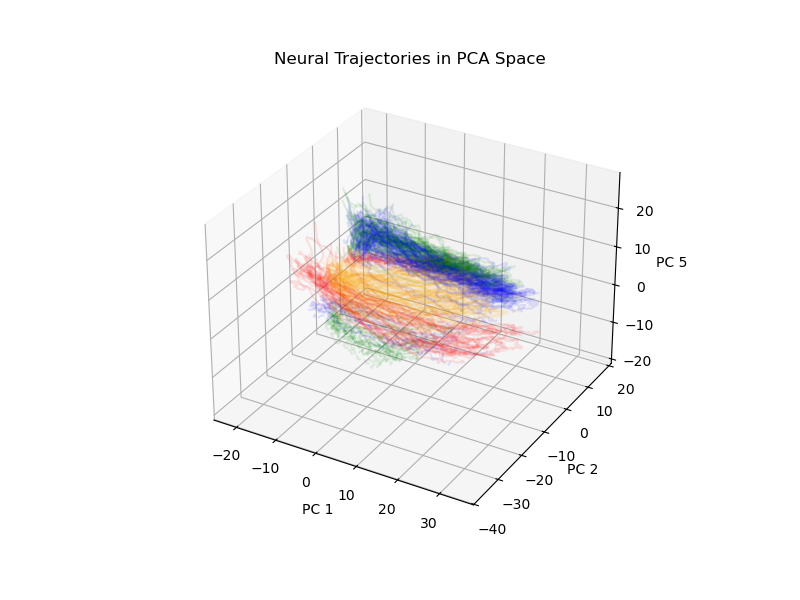

In [40]:
# plot PCs 1, 2, 5 (5 shows load?)

# make a graded colorscale for each combo
# trial_combos, combo_labels = np.unique(trial_labels_corr[load3_idxs, 2:5], axis=0, return_inverse=True)  # unique stim1/2/3 combinations for load 3

plot_PCS = [0, 1, 4]  # PCs to plot

# load3 labels
label_leftout = [np.setdiff1d(np.arange(4), combo)[0] for combo in trial_labels_corr[load3_idxs, 2:5]]  # which stim was left out
n_combos = len(label_leftout)

# load1 labels
load1_stims = trial_labels_corr[load1_idxs, 2].astype(int)  # stim1 for load 1

colors_load3 = ['blue', 'orange', 'green', 'red']  # fixed colors for each left-out stim
# colors_load1 = [shift_hue(c) for c in colors_load3]  # shifted colors for load 1

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot(load1_comps.mean(axis=0)[: :, 0], load3_comps.mean(axis=0)[:, 1], load3_comps.mean(axis=0)[:, 2], label='Load 3', color='orange')

# lightly plot individual trials for each load
for i in range(n_trials_load1):
        # ax.plot(load1_comps[i, :, 0], load1_comps[i, :, 1], load1_comps[i, :, 2], color='gray', alpha=0.1)
        ax.plot(load1_comps[i, :, plot_PCS[0]], load1_comps[i, :, plot_PCS[1]], load1_comps[i, :, plot_PCS[2]], 
                color=colors_load3[load1_stims[i]], alpha=0.1,ls='--')
for i in range(n_trials_load3):
    # ax.plot(load3_comps[i, :, 0], load3_comps[i, :, 1], load3_comps[i, :, 2], color=colors[load3_stims[i]], alpha=0.1)
    ax.plot(load3_comps[i, :, plot_PCS[0]], load3_comps[i, :, plot_PCS[1]], load3_comps[i, :, plot_PCS[2]], 
            color=colors_load3[label_leftout[i]], alpha=0.1)
    
ax.set_xlabel(f'PC {plot_PCS[0] + 1}')
ax.set_ylabel(f'PC {plot_PCS[1] + 1}')
ax.set_zlabel(f'PC {plot_PCS[2] + 1}')
ax.set_title('Neural Trajectories in PCA Space')
# ax.legend()
plt.show()

#### multiple models

In [21]:
n_components = 10
varexps = np.zeros((len(model_names), n_components, 2)) # models x components x load

for i, model_name in enumerate(model_names):
    other_labels='precomputed.'
    _, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                                all_models_dir = all_models_dir, load_LFP=False)

    trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels='precomputed.',
            all_models_dir=all_models_dir
        )
    
    # cut trials to maintenance period only
    rates_maint = np.zeros((rates_corr.shape[0], rates_corr.shape[1], settings["delay"])) # trials x neurons x time
    for k in range(rates_corr.shape[0]):
        load = trial_labels_corr[k, 0]
        delay_start = int(settings["stim_on"] + settings["stim_dur"] * load)
        delay_end = int(delay_start + settings["delay"])
        rates_maint[k, :, :] = rates_corr[k, :, delay_start:delay_end]

    for j, load in enumerate([1, 3]):
        load_idxs = np.where(trial_labels_corr[:, 0] == load)[0]
        load_rates = rates_maint[load_idxs, :, :] # trials x neurons x time
        PCA_load = PCA(n_components=n_components)
        PCA_load.fit(load_rates.mean(axis=0)) # mean across trials; PCA of neurons x time
        varexps[i, :, j] = PCA_load.explained_variance_ratio_

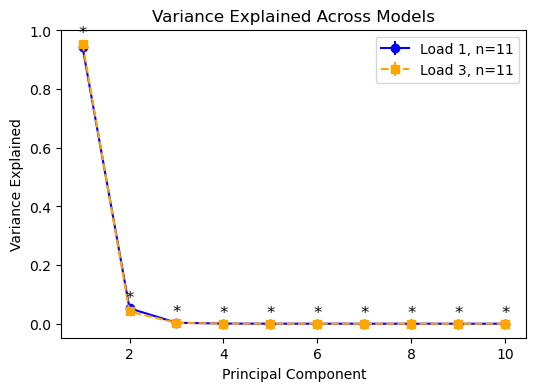

In [23]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
mean_varexps = np.mean(varexps, axis=0) # components x load
std_varexps = np.std(varexps, axis=0)
plt.errorbar(x, mean_varexps[:, 0], yerr=std_varexps[:, 0], fmt='o-', color='blue', label=f'Load 1, n={len(model_names)}')
plt.errorbar(x, mean_varexps[:, 1], yerr=std_varexps[:, 1], fmt='s--', color='orange', label=f'Load 3, n={len(model_names)}')
for i in range(n_components):
    p, _ = wilcoxon(varexps[:, i, 0], varexps[:, i, 1])
    if p < 0.05:
        plt.text(x[i], max(mean_varexps[i, 0], mean_varexps[i, 1]) + 0.01, '*', ha='center', va='bottom', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained Across Models')
plt.legend()
plt.show()

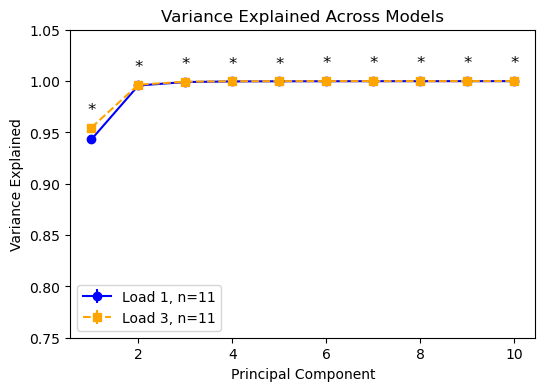

In [24]:
# make line plot with error bars for each component across models
from scipy.stats import wilcoxon

plt.figure(figsize=(6,4))
x = np.arange(1, n_components+1)
varexp_runningsum = np.cumsum(varexps, axis=1) # models x components x load
mean_varexps = np.mean(varexp_runningsum, axis=0) # components x load
std_varexps = np.std(varexp_runningsum, axis=0)
plt.errorbar(x, mean_varexps[:, 0], yerr=std_varexps[:, 0], fmt='o-', color='blue', label=f'Load 1, n={len(model_names)}')
plt.errorbar(x, mean_varexps[:, 1], yerr=std_varexps[:, 1], fmt='s--', color='orange', label=f'Load 3, n={len(model_names)}')
for i in range(n_components):
    p, _ = wilcoxon(varexp_runningsum[:, i, 0], varexp_runningsum[:, i, 1])
    if p < 0.05:
        plt.text(x[i], max(mean_varexps[i, 0], mean_varexps[i, 1]) + 0.01, '*', ha='center', va='bottom', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.ylim(0.75, 1.05)
plt.title('Variance Explained Across Models')
plt.legend()
# plt.tight_layout()
plt.show()

## cross-validated PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
import numpy as np

def cv_pca_reconstruction_error(trials_neurons_time, n_components_list, n_folds=5):
    """
    trials_neurons_time: shape (n_trials, n_neurons, n_time)
    Returns reconstruction error per n_components, cross-validated over trials.
    """
    n_trials, n_neurons, n_time = trials_neurons_time.shape
    kf = KFold(n_splits=n_folds, shuffle=True)
    errors = np.zeros((n_folds, len(n_components_list)))

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_trials))):
        train_avg = trials_neurons_time[train_idx].mean(axis=0)  # neurons x time
        test_avg = trials_neurons_time[test_idx].mean(axis=0)

        # z-score using train statistics only
        mu = train_avg.mean(axis=1, keepdims=True)
        sd = train_avg.std(axis=1, keepdims=True) + 1e-8
        train_z = (train_avg - mu) / sd
        test_z = (test_avg - mu) / sd  # apply train normalization to test

        for k_i, k in enumerate(n_components_list):
            pca = PCA(n_components=k)
            pca.fit(train_z.T)  # time x neurons
            test_proj = pca.transform(test_z.T)
            test_recon = pca.inverse_transform(test_proj)
            err = np.mean((test_z.T - test_recon)**2)
            errors[fold_i, k_i] = err

    return errors  # shape (n_folds, n_components_list)

In [ ]:
def participation_ratio(eigenvalues):
    ev = np.array(eigenvalues)
    return (ev.sum()**2) / (ev**2).sum()

def bootstrap_pr(trials_neurons_time, n_boot=1000, n_sub=None):
    n_trials = trials_neurons_time.shape[0]
    n_sub = n_sub or n_trials
    prs = []
    for _ in range(n_boot):
        idx = np.random.choice(n_trials, size=n_sub, replace=True)
        avg = trials_neurons_time[idx].mean(axis=0)
        avg_z = (avg - avg.mean(axis=1, keepdims=True)) / (avg.std(axis=1, keepdims=True) + 1e-8)
        pca = PCA().fit(avg_z.T)
        prs.append(participation_ratio(pca.explained_variance_))
    return np.array(prs)

pr_load1 = bootstrap_pr(load1_trials, n_sub=n_min)
pr_load3 = bootstrap_pr(load3_trials, n_sub=n_min)

In [ ]:
diff = pr_load3 - pr_load1
ci_lower, ci_upper = np.percentile(diff, [2.5, 97.5])
p_value = np.mean(diff <= 0) * 2  # two-sided, crude but standard for bootstrap

In [48]:
model_name = model_names[0]

other_labels='precomputed.'
_, rates_data_balance = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)

trial_labels_balance, trial_perfs_balance, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )

# let's start by getting the mean firing rates for each neuron across trial types, only in correct trials
correct_idxs = np.where(trial_perfs_balance == 1)[0]
rates_corr = rates_data_balance[correct_idxs, :, 25:] # trials x neurons x time
trial_labels_corr = trial_labels_balance[correct_idxs, :] # trials x labels

load1_idxs = np.where(trial_labels_corr[:, 0] == 1)[0]
load3_idxs = np.where(trial_labels_corr[:, 0] == 3)[0]

PR load-1: 3.12 [3.02, 3.23]
PR load-3: 3.84 [3.71, 3.99]
Difference CI: [0.56, 0.90], bootstrap p = 0.0000


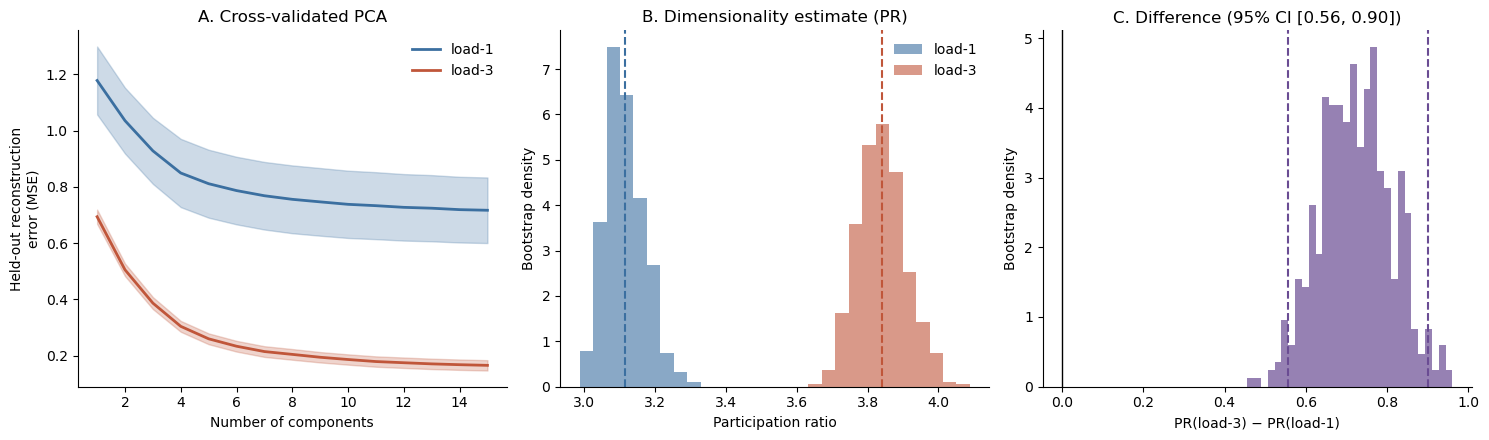

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

rng = np.random.default_rng(0)


load1_trials =  rates_corr[load1_idxs,:,:] # trials x neurons x time
load3_trials = rates_corr[load3_idxs,:,:] # trials x neurons x time
# ----------------------------------------------------------------------


def zscore_train_apply(train_avg, test_avg=None):
    mu = train_avg.mean(axis=1, keepdims=True)
    sd = train_avg.std(axis=1, keepdims=True) + 1e-8
    train_z = (train_avg - mu) / sd
    if test_avg is None:
        return train_z
    test_z = (test_avg - mu) / sd
    return train_z, test_z


def cv_pca_reconstruction_error(trials, n_components_list, n_folds=5):
    n_trials_local = trials.shape[0]
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
    errors = np.full((n_folds, len(n_components_list)), np.nan)

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_trials_local))):
        train_avg = trials[train_idx].mean(axis=0)
        test_avg = trials[test_idx].mean(axis=0)
        train_z, test_z = zscore_train_apply(train_avg, test_avg)

        for k_i, k in enumerate(n_components_list):
            pca = PCA(n_components=k)
            pca.fit(train_z.T)
            test_proj = pca.transform(test_z.T)
            test_recon = pca.inverse_transform(test_proj)
            errors[fold_i, k_i] = np.mean((test_z.T - test_recon) ** 2)

    return errors


def participation_ratio(eigvals):
    ev = np.asarray(eigvals)
    return (ev.sum() ** 2) / (ev ** 2).sum()


def bootstrap_pr(trials, n_boot=500, n_sub=None):
    n_trials_local = trials.shape[0]
    n_sub = n_sub or n_trials_local
    prs = np.zeros(n_boot)
    for b in range(n_boot):
        idx = rng.choice(n_trials_local, size=n_sub, replace=True)
        avg = trials[idx].mean(axis=0)
        avg_z = zscore_train_apply(avg)
        pca = PCA().fit(avg_z.T)
        prs[b] = participation_ratio(pca.explained_variance_)
    return prs


# match trial counts between conditions
n_min = min(load1_trials.shape[0], load3_trials.shape[0])

# --- Step 2: cross-validated reconstruction error ---
n_components_list = list(range(1, 16))
err1 = cv_pca_reconstruction_error(load1_trials, n_components_list)
err3 = cv_pca_reconstruction_error(load3_trials, n_components_list)

# --- Step 3/4: bootstrap participation ratio, trial-count matched ---
pr1 = bootstrap_pr(load1_trials, n_sub=n_min)
pr3 = bootstrap_pr(load3_trials, n_sub=n_min)
diff = pr3 - pr1
ci_lo, ci_hi = np.percentile(diff, [2.5, 97.5])
p_value = np.mean(diff <= 0) * 2

# ----------------------------------------------------------------------
# FIGURE
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel A: CV reconstruction error vs n_components
ax = axes[0]
for err, label, color in [(err1, "load-1", "#3b6fa0"), (err3, "load-3", "#c0563a")]:
    mean_err = err.mean(axis=0)
    sem_err = err.std(axis=0) / np.sqrt(err.shape[0])
    ax.plot(n_components_list, mean_err, label=label, color=color, lw=2)
    ax.fill_between(n_components_list, mean_err - sem_err, mean_err + sem_err,
                     color=color, alpha=0.25)
ax.set_xlabel("Number of components")
ax.set_ylabel("Held-out reconstruction\nerror (MSE)")
ax.set_title("A. Cross-validated PCA")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Panel B: bootstrap PR distributions
ax = axes[1]
bins = np.linspace(min(pr1.min(), pr3.min()), max(pr1.max(), pr3.max()), 30)
ax.hist(pr1, bins=bins, alpha=0.6, color="#3b6fa0", label="load-1", density=True)
ax.hist(pr3, bins=bins, alpha=0.6, color="#c0563a", label="load-3", density=True)
ax.axvline(pr1.mean(), color="#3b6fa0", ls="--", lw=1.5)
ax.axvline(pr3.mean(), color="#c0563a", ls="--", lw=1.5)
ax.set_xlabel("Participation ratio")
ax.set_ylabel("Bootstrap density")
ax.set_title("B. Dimensionality estimate (PR)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Panel C: bootstrap difference distribution with CI
ax = axes[2]
ax.hist(diff, bins=30, color="#6a4c93", alpha=0.7, density=True)
ax.axvline(0, color="k", lw=1, ls="-")
ax.axvline(ci_lo, color="#6a4c93", lw=1.5, ls="--")
ax.axvline(ci_hi, color="#6a4c93", lw=1.5, ls="--")
ax.set_xlabel("PR(load-3) − PR(load-1)")
ax.set_ylabel("Bootstrap density")
ax.set_title(f"C. Difference (95% CI [{ci_lo:.2f}, {ci_hi:.2f}])")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/dimensionality_comparison.png", dpi=200, bbox_inches="tight")
# plt.savefig("/mnt/user-data/outputs/dimensionality_comparison.pdf", bbox_inches="tight")

print(f"PR load-1: {pr1.mean():.2f} [{np.percentile(pr1,2.5):.2f}, {np.percentile(pr1,97.5):.2f}]")
print(f"PR load-3: {pr3.mean():.2f} [{np.percentile(pr3,2.5):.2f}, {np.percentile(pr3,97.5):.2f}]")
print(f"Difference CI: [{ci_lo:.2f}, {ci_hi:.2f}], bootstrap p = {p_value:.4f}")

A few things to flag explicitly in the paper given this design: state that trial counts were matched via bootstrap subsampling (n_sub=n_min) so the result isn't an artifact of one condition having more trials, that z-scoring statistics were computed on training data only and applied to held-out data (preventing leakage in panel A), and report your n_time/n_neurons ratio so reviewers can see PR isn't bumping against a rank ceiling.

In [51]:
# running a null with time-shuffled data to see if the difference is significant

"""
Temporal shuffle null control for the load-1 vs load-3 dimensionality comparison.
------------------------------------------------------------------------------
Logic: shuffle each neuron's time axis ONCE per null iteration (a single
circular shift or permutation per neuron), applying that SAME shuffle across
all trials of a condition. This destroys the temporal alignment BETWEEN
neurons -- the thing population dimensionality actually depends on -- while
preserving each neuron's own trial-to-trial reliability and (for circular
shift) its autocorrelation/smoothness. If a real PR difference between
load-1 and load-3 exceeds what this null produces, that's evidence the
difference reflects genuine cross-neuron temporal coordination rather than
single-neuron statistics or trial-count effects.

Note: shuffling independently on every individual trial (rather than once
per neuron, held fixed across trials) is a common mistake here -- it also
destroys each neuron's own reliable signal, causing trial-averaging to wash
everything toward a near-flat trace and producing an unstable, uninformative
null. The fixed-per-neuron version below avoids that.

Two shuffle variants are included:
  1. full random permutation of timepoints per neuron per trial (most aggressive,
     destroys ALL temporal structure including smoothness)
  2. circular shift per neuron per trial (preserves local smoothness/autocorr,
     only destroys the *alignment* across neurons) -- often preferred since it's
     a more conservative null that doesn't also remove smoothness as a confound

Run this after dimensionality_figure.py (or paste the relevant helper functions
in directly) — it reuses make_condition_trials, participation_ratio etc.
"""

data_rng = np.random.default_rng(0)   
rng = np.random.default_rng(1)        # used for bootstrap/shuffle randomness


load1_trials =  rates_corr[load1_idxs,:,:] # trials x neurons x time
load3_trials = rates_corr[load3_idxs,:,:] # trials x neurons x time
# ----------------------------------------------------------------------

def shuffle_trials_temporally(trials, mode="circular"):
    """
    trials: (n_trials, n_neurons, n_time)
    Shuffle each neuron's time axis ONCE per call, applying the SAME shift/
    permutation to that neuron across all trials. This is important: if you
    instead shuffle independently on every single trial, trial-averaging
    will wash out each neuron's own signal (not just cross-neuron alignment),
    collapsing every neuron toward a near-flat trace and producing an
    unstable, degenerate null. Shuffling once per neuron and holding it fixed
    across trials preserves each neuron's trial-to-trial reliability while
    only destroying the temporal alignment *between* neurons -- which is
    exactly the null hypothesis you want to test against (population
    dimensionality arising from cross-neuron temporal coordination).

    mode: "circular" (shift, preserves each neuron's autocorrelation/smoothness)
          "permute"  (full random reordering, destroys all temporal structure)
    Returns a new array of the same shape.
    """
    n_tr, n_neu, n_t = trials.shape
    shuffled = np.empty_like(trials)
    for neu in range(n_neu):
        if mode == "circular":
            shift = rng.integers(0, n_t)
            shuffled[:, neu, :] = np.roll(trials[:, neu, :], shift, axis=-1)
        elif mode == "permute":
            perm = rng.permutation(n_t)
            shuffled[:, neu, :] = trials[:, neu, perm]
        else:
            raise ValueError("mode must be 'circular' or 'permute'")
    return shuffled


Observed PR difference (load-3 - load-1): 0.725
Null distribution mean: -1.072, 95% range: [-1.351, -0.816]
Empirical p-value (null >= observed): 0.0000


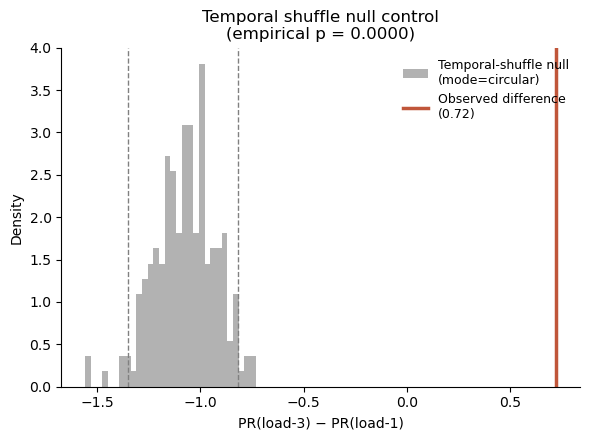

In [53]:

# ----------------------------------------------------------------------
# Real (observed) PR difference, trial-count matched (calculated above)
# ----------------------------------------------------------------------
n_min = min(load1_trials.shape[0], load3_trials.shape[0])
pr1_real = pr1
pr3_real = pr3
observed_diff = pr3_real.mean() - pr1_real.mean()

# ----------------------------------------------------------------------
# Null distribution: shuffle each condition's trials temporally, recompute
# the PR difference many times. Each iteration re-shuffles AND re-bootstraps
# trial selection, so the null reflects both sources of variability.
# ----------------------------------------------------------------------
N_NULL_ITERS = 200
SHUFFLE_MODE = "circular"  # use "permute" for the more aggressive variant

null_diffs = np.zeros(N_NULL_ITERS)

for i in range(N_NULL_ITERS):
    l1_shuf = shuffle_trials_temporally(load1_trials, mode=SHUFFLE_MODE)
    l3_shuf = shuffle_trials_temporally(load3_trials, mode=SHUFFLE_MODE)

    idx1 = rng.choice(l1_shuf.shape[0], size=n_min, replace=True)
    idx3 = rng.choice(l3_shuf.shape[0], size=n_min, replace=True)

    avg1 = zscore_train_apply(l1_shuf[idx1].mean(axis=0))
    avg3 = zscore_train_apply(l3_shuf[idx3].mean(axis=0))

    pr1_null = participation_ratio(PCA().fit(avg1.T).explained_variance_)
    pr3_null = participation_ratio(PCA().fit(avg3.T).explained_variance_)

    null_diffs[i] = pr3_null - pr1_null

# empirical p-value: how often does the null exceed the observed difference?
p_value_null = np.mean(null_diffs >= observed_diff)
null_mean = null_diffs.mean()
null_ci = np.percentile(null_diffs, [2.5, 97.5])

print(f"Observed PR difference (load-3 - load-1): {observed_diff:.3f}")
print(f"Null distribution mean: {null_mean:.3f}, 95% range: [{null_ci[0]:.3f}, {null_ci[1]:.3f}]")
print(f"Empirical p-value (null >= observed): {p_value_null:.4f}")

# ----------------------------------------------------------------------
# FIGURE: null distribution vs observed difference
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(null_diffs, bins=30, color="gray", alpha=0.6, density=True,
        label=f"Temporal-shuffle null\n(mode={SHUFFLE_MODE})")
ax.axvline(observed_diff, color="#c0563a", lw=2.5,
           label=f"Observed difference\n({observed_diff:.2f})")
ax.axvline(null_ci[0], color="gray", lw=1, ls="--")
ax.axvline(null_ci[1], color="gray", lw=1, ls="--")
ax.set_xlabel("PR(load-3) − PR(load-1)")
ax.set_ylabel("Density")
ax.set_title(f"Temporal shuffle null control\n(empirical p = {p_value_null:.4f})")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/temporal_shuffle_null.png", dpi=200, bbox_inches="tight")
# plt.savefig("/mnt/user-data/outputs/temporal_shuffle_null.pdf", bbox_inches="tight")

Observed PR difference (load-3 - load-1): 0.725
Null distribution mean: 0.048, 95% range: [-1.165, 1.356]
Empirical p-value (null >= observed): 0.1150


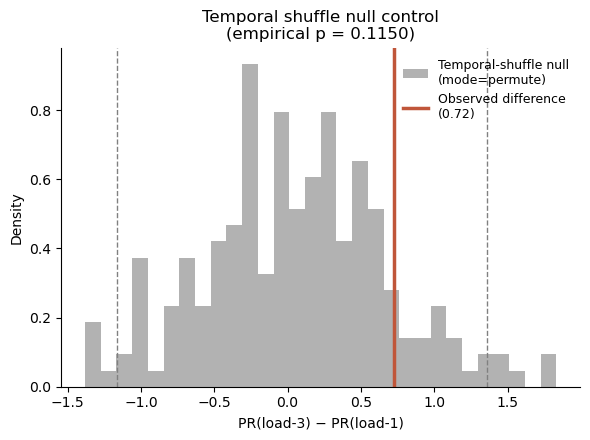

In [54]:
N_NULL_ITERS = 200
SHUFFLE_MODE = "permute"  # use "permute" for the more aggressive variant

null_diffs = np.zeros(N_NULL_ITERS)

for i in range(N_NULL_ITERS):
    l1_shuf = shuffle_trials_temporally(load1_trials, mode=SHUFFLE_MODE)
    l3_shuf = shuffle_trials_temporally(load3_trials, mode=SHUFFLE_MODE)

    idx1 = rng.choice(l1_shuf.shape[0], size=n_min, replace=True)
    idx3 = rng.choice(l3_shuf.shape[0], size=n_min, replace=True)

    avg1 = zscore_train_apply(l1_shuf[idx1].mean(axis=0))
    avg3 = zscore_train_apply(l3_shuf[idx3].mean(axis=0))

    pr1_null = participation_ratio(PCA().fit(avg1.T).explained_variance_)
    pr3_null = participation_ratio(PCA().fit(avg3.T).explained_variance_)

    null_diffs[i] = pr3_null - pr1_null

# empirical p-value: how often does the null exceed the observed difference?
p_value_null = np.mean(null_diffs >= observed_diff)
null_mean = null_diffs.mean()
null_ci = np.percentile(null_diffs, [2.5, 97.5])

print(f"Observed PR difference (load-3 - load-1): {observed_diff:.3f}")
print(f"Null distribution mean: {null_mean:.3f}, 95% range: [{null_ci[0]:.3f}, {null_ci[1]:.3f}]")
print(f"Empirical p-value (null >= observed): {p_value_null:.4f}")

# ----------------------------------------------------------------------
# FIGURE: null distribution vs observed difference
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(null_diffs, bins=30, color="gray", alpha=0.6, density=True,
        label=f"Temporal-shuffle null\n(mode={SHUFFLE_MODE})")
ax.axvline(observed_diff, color="#c0563a", lw=2.5,
           label=f"Observed difference\n({observed_diff:.2f})")
ax.axvline(null_ci[0], color="gray", lw=1, ls="--")
ax.axvline(null_ci[1], color="gray", lw=1, ls="--")
ax.set_xlabel("PR(load-3) − PR(load-1)")
ax.set_ylabel("Density")
ax.set_title(f"Temporal shuffle null control\n(empirical p = {p_value_null:.4f})")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/temporal_shuffle_null.png", dpi=200, bbox_inches="tight")
# plt.savefig("/mnt/user-data/outputs/temporal_shuffle_null.pdf", bbox_inches="tight")

*What each control actually tests*

Think of your neural population data as having two separable layers of structure: (1) what each individual neuron does on its own — its amplitude, variance, how "peaky" or flat its response is, how many neurons are active at all — and (2) how neurons are coordinated with each other in time — whether neuron A's peak lines up with neuron B's peak, whether there are shared temporal motifs that multiple neurons participate in together.  

The circular shift control only scrambles layer (2). It rotates each neuron's full time series by a random amount, but the shape of that neuron's response — its smoothness, its amplitude, its overall variance — is completely untouched, just shifted in time. So when you trial-average and recompute PR on circularly-shifted data, you're asking: "if neurons still did exactly the same things, but at uncoordinated/misaligned times relative to each other, would I still see this much dimensionality difference?" The fact that this came back highly significant (p < 0.0001) means no — once you scramble the timing relationships between neurons, the dimensionality difference vanishes or reverses. That tells you something real and specific: load-3 has more genuine cross-neuron temporal coordination than load-1, not just busier neurons.  
The permute control scrambles both layers at once. Full random reordering of timepoints destroys smoothness too, which changes things like each neuron's effective variance structure and the shape of its autocorrelation, not just its alignment with other neurons. When this null comfortably contains your real difference (p = 0.115), it means: "if I destroy everything about temporal structure, including each neuron's own smoothness, I can generate a PR difference this large just from neuron-level statistics and noise, without needing any real coordination at all." In other words, this control is a much lower, easier bar to clear, and your real effect didn't clearly clear it.  

*Putting the two together*  
The honest interpretation is that your real data shows a PR difference that depends on cross-neuron temporal coordination (since destroying just that, via circular shift, kills the effect) — but the size of that difference isn't dramatically larger than what arbitrary, fully scrambled single-neuron statistics could in principle produce by chance (since permute's null already covers the range your real value falls in). This isn't necessarily bad news; it's pointing you toward checking whether load-3 also differs from load-1 in basic single-neuron properties, since those properties feed into PR too and could be a substantial part of the story alongside coordination.

#### checking neuron-level statistics

variance — each neuron's own variance over time directly feeds into the covariance matrix that PCA operates on, so if load-3 neurons simply have higher variance across the board (regardless of coordination), that alone inflates PR. In this synthetic run the CI includes zero, so variance differences aren't the driver here.
amplitude (peak-to-trough range) — a cruder, more interpretable version of the same idea; large response swings without necessarily more coordination.  
mean_activity — overall activity level; mostly a sanity check, shouldn't itself affect PR much since you're z-scoring, but useful to report.  
reliability (leave-one-out trial correlation) — this is important and easy to overlook: if load-3 neurons are simply more reliable trial-to-trial (less noisy), your trial-averaged signal will look cleaner and may show more genuine low-dimensional or high-dimensional structure for reasons unrelated to "true" coordination — it's partly a signal-to-noise story rather than a geometry story.  
frac_active — if more neurons cross some activity threshold in load-3, you simply have more neurons potentially contributing independent dimensions, which mechanically can raise PR.  
kurtosis — this is the one that came out significant in the synthetic example (CI [0.04, 0.24], excluding zero), meaning load-3 neurons' response shapes are less peaked/more broadly distributed across time than load-1's. That's actually a meaningful single-neuron-level difference that could plausibly help explain part of your PR difference, independent of cross-neuron coordination.  


The practical next step: run this on your real data and look at which of these metrics show CIs excluding zero. If one or two single-neuron properties (like reliability or kurtosis here) show a credible difference between conditions, you have a concrete, testable account of part of the story, and you can discuss in the paper that the dimensionality difference is partly attributable to that specific single-neuron-level change rather than treating "population dimensionality" as a mysterious black box. If none of these differ but your circular-shift control is still significant, that's actually the cleanest possible story: it more strongly implicates pure cross-neuron coordination, since you've ruled out the simpler single-neuron explanations as the driver.

load-1: n_active = 80 (100.0%)
load-3: n_active = 80 (100.0%)

variance       : load3-load1 diff = +0.059  95% CI [-0.141, +0.260]
amplitude      : load3-load1 diff = +0.301  95% CI [-0.019, +0.618]
mean_activity  : load3-load1 diff = -0.002  95% CI [-0.008, +0.003]
reliability    : load3-load1 diff = +0.059  95% CI [-0.001, +0.116]
kurtosis       : load3-load1 diff = +0.141  95% CI [+0.040, +0.244]  <-- CI excludes 0


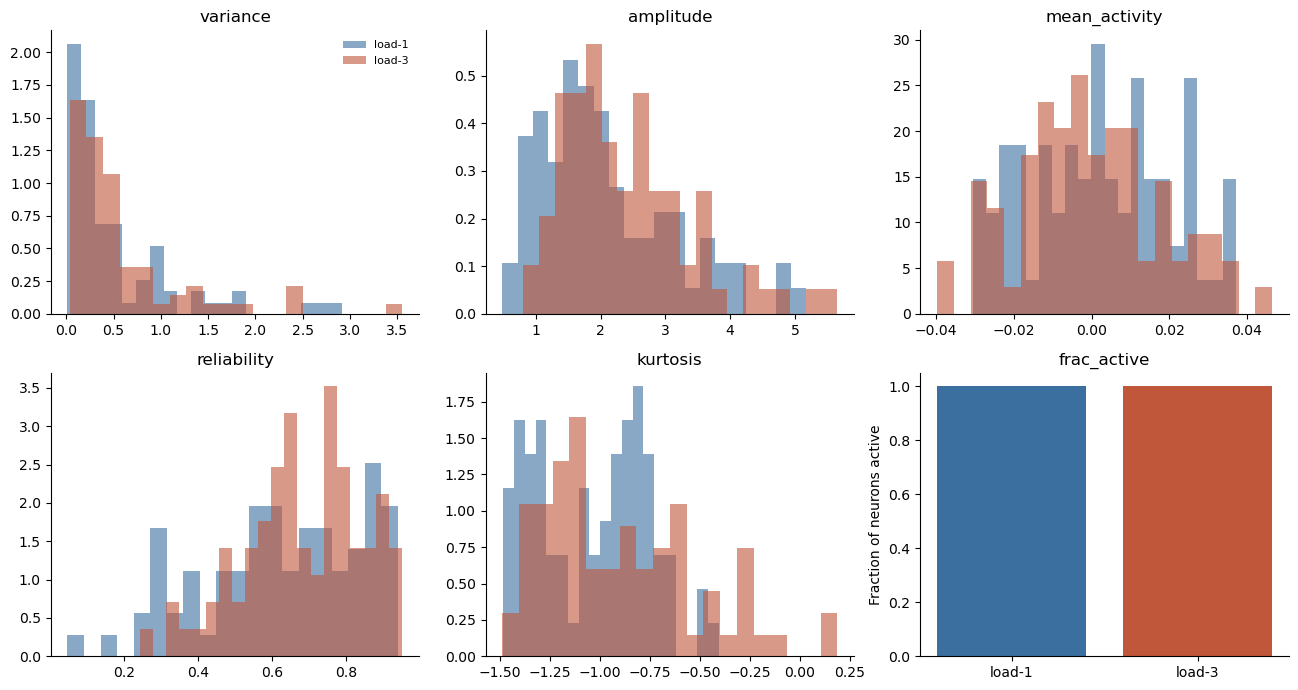

In [56]:
"""
Per-neuron statistics: load-1 vs load-3
-----------------------------------------------------------------
These metrics characterize single-neuron response properties, independent
of any cross-neuron temporal alignment. Comparing them between conditions
helps you figure out how much of a PR/dimensionality difference could be
"explained away" by basic single-neuron statistics (amplitude, variance,
how many neurons are active at all) vs. genuine population coordination.

Expects:
    load1_trials  # shape (n_trials_load1, n_neurons, n_time)
    load3_trials  # shape (n_trials_load3, n_neurons, n_time)
"""

from scipy import stats

rng = np.random.default_rng(0)


def per_neuron_stats(trials, active_thresh_z=1.0):
    """
    trials: (n_trials, n_neurons, n_time)
    Returns a dict of per-neuron arrays (length n_neurons), computed on the
    trial-averaged response (to match what feeds into your PCA/PR analysis).
    """
    trial_avg = trials.mean(axis=0)  # n_neurons x n_time
 
    # 1. Variance of each neuron's trial-averaged time course
    #    -- directly relevant since PCA/PR operates on this covariance
    variance = trial_avg.var(axis=1)
 
    # 2. Peak-to-trough amplitude (range) of each neuron's response
    amplitude = trial_avg.max(axis=1) - trial_avg.min(axis=1)
 
    # 3. Mean firing rate / activity level
    mean_activity = trial_avg.mean(axis=1)
 
    # 4. Trial-to-trial reliability: correlate each trial's time course with
    #    the mean of the OTHER trials, average over trials (leave-one-out).
    #    High reliability = neuron's response shape is consistent across trials.
    n_trials_local, n_neurons, n_time = trials.shape
    reliability = np.zeros(n_neurons)
    for neu in range(n_neurons):
        corrs = []
        for tr in range(n_trials_local):
            other_mean = np.delete(trials[:, neu, :], tr, axis=0).mean(axis=0)
            if other_mean.std() > 0 and trials[tr, neu, :].std() > 0:
                r = np.corrcoef(trials[tr, neu, :], other_mean)[0, 1]
                corrs.append(r)
        reliability[neu] = np.nanmean(corrs) if corrs else np.nan
 
    # 5. "Active" neuron flag: z-score each neuron's own response and check
    #    whether it deviates from baseline by more than active_thresh_z at
    #    any point. (Adjust this definition to match your field's convention,
    #    e.g. relative to a pre-stimulus baseline window if you have one.)
    z = (trial_avg - trial_avg.mean(axis=1, keepdims=True)) / (trial_avg.std(axis=1, keepdims=True) + 1e-8)
    is_active = (np.abs(z).max(axis=1) > active_thresh_z)
 
    # 6. Sparsity / kurtosis of the response -- a flat, broadly-active
    #    response has low kurtosis; a narrow, peaky response has high kurtosis.
    kurtosis = stats.kurtosis(trial_avg, axis=1)
 
    return {
        "variance": variance,
        "amplitude": amplitude,
        "mean_activity": mean_activity,
        "reliability": reliability,
        "is_active": is_active,
        "kurtosis": kurtosis,
        "n_active": is_active.sum(),
        "frac_active": is_active.mean(),
    }
 
 
def compare_conditions(stats1, stats3, metric, n_boot=2000):
    """
    Bootstrap comparison of a given per-neuron metric between conditions.
    Resamples neurons (with replacement) to get a CI on the mean difference.
    """
    v1, v3 = stats1[metric], stats3[metric]
    obs_diff = np.nanmean(v3) - np.nanmean(v1)
 
    boot_diffs = np.zeros(n_boot)
    for b in range(n_boot):
        s1 = rng.choice(v1, size=len(v1), replace=True)
        s3 = rng.choice(v3, size=len(v3), replace=True)
        boot_diffs[b] = np.nanmean(s3) - np.nanmean(s1)
 
    ci = np.percentile(boot_diffs, [2.5, 97.5])
    return obs_diff, ci, boot_diffs
 
 
# ----------------------------------------------------------------------
# Example usage (replace load1_trials / load3_trials with your real data)
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # --- synthetic placeholder data, same generator as earlier scripts ---
    n_neurons, n_time, n_trials = 80, 60, 40
    t = np.linspace(0, 1, n_time)
 
    def make_condition_trials(n_latents, n_trials, noise_std=0.6):
        latents = np.array([
            np.sin(2 * np.pi * (k + 1) * t + k) * np.exp(-t * 0.5 * k)
            for k in range(n_latents)
        ])
        decay = np.array([1.0 / (k + 1) for k in range(n_latents)])
        weights = rng.normal(size=(n_neurons, n_latents)) * decay
        clean = weights @ latents
        trials = np.zeros((n_trials, n_neurons, n_time))
        for tr in range(n_trials):
            trials[tr] = clean + rng.normal(scale=noise_std, size=clean.shape)
        return trials
 
    load1_trials = make_condition_trials(2, n_trials)
    load3_trials = make_condition_trials(5, n_trials)
    # ----------------------------------------------------------------
 
    stats1 = per_neuron_stats(load1_trials)
    stats3 = per_neuron_stats(load3_trials)
 
    print(f"load-1: n_active = {stats1['n_active']} ({stats1['frac_active']:.1%})")
    print(f"load-3: n_active = {stats3['n_active']} ({stats3['frac_active']:.1%})")
    print()
 
    metrics_to_check = ["variance", "amplitude", "mean_activity", "reliability", "kurtosis"]
    results = {}
    for m in metrics_to_check:
        obs_diff, ci, boot_diffs = compare_conditions(stats1, stats3, m)
        results[m] = (obs_diff, ci)
        sig = "  <-- CI excludes 0" if (ci[0] > 0 or ci[1] < 0) else ""
        print(f"{m:15s}: load3-load1 diff = {obs_diff:+.3f}  95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]{sig}")
 
    # ------------------------------------------------------------------
    # FIGURE: per-neuron metric comparisons
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    axes = axes.flatten()
 
    for i, m in enumerate(metrics_to_check):
        ax = axes[i]
        ax.hist(stats1[m], bins=20, alpha=0.6, color="#3b6fa0", label="load-1", density=True)
        ax.hist(stats3[m], bins=20, alpha=0.6, color="#c0563a", label="load-3", density=True)
        ax.set_title(m)
        ax.spines[["top", "right"]].set_visible(False)
        if i == 0:
            ax.legend(frameon=False, fontsize=8)
 
    # last panel: fraction active comparison (bar)
    ax = axes[-1]
    ax.bar(["load-1", "load-3"], [stats1["frac_active"], stats3["frac_active"]],
           color=["#3b6fa0", "#c0563a"])
    ax.set_ylabel("Fraction of neurons active")
    ax.set_title("frac_active")
    ax.spines[["top", "right"]].set_visible(False)
 
    plt.tight_layout()